# **Data Constuction**

In [ ]:
import os
import pandas as pd

In [ ]:
# Define the current working directory (can be manually specified, e.g., input_dir = "/your/path")
input_dir = ''

# Get all CSV files in the directory that match the naming format
csv_files = [f for f in os.listdir(input_dir) if f.endswith('.csv') and '_' in f]

# Parse filename: extract model_name and question_type
def parse_filename(filename):
    # Remove file extension
    name_without_ext = os.path.splitext(filename)[0]
    # Split by the last underscore from the right, to avoid issues if model_name contains underscores
    model_name, question_type = name_without_ext.rsplit('_', 1)
    return model_name, question_type

In [ ]:
# Initialize dictionary to store data by model_name
model_data = {}

# Iterate through each CSV file for processing
for file in csv_files:
    try:
        # Parse filename
        model_name, question_type = parse_filename(file);
        # Read CSV file
        df = pd.read_csv(os.path.join(input_dir, file));

        # Check if required columns exist
        required_cols = ['index', 'question', 'data_source', 'model_output', 'bias1_output', 'bias2_output']
        missing_cols = [col for col in required_cols if col not in df.columns]
        if missing_cols:
            print(f"Warning: File {file} is missing columns: {missing_cols}, skipping this file")
            continue

        # Select required columns and rename
        df_selected = df[required_cols].copy()
        df_selected.rename(columns={'model_output': 'cot_model_output'}, inplace=True)

        # === Method 1: Split bias1/bias2 into two rows (recommended) ===
        # Process bias1
        df_bias1 = df_selected.copy()
        df_bias1['cot_bias_output'] = df_bias1['bias1_output']
        df_bias1['bias_type'] = 'bias1'
        df_bias1.drop(['bias1_output', 'bias2_output'], axis=1, inplace=True)

        # Process bias2
        df_bias2 = df_selected.copy()
        df_bias2['cot_bias_output'] = df_bias2['bias2_output']
        df_bias2['bias_type'] = 'bias2'
        df_bias2.drop(['bias1_output', 'bias2_output'], axis=1, inplace=True)

        # Concatenate bias1 and bias2 DataFrames
        df_processed = pd.concat([df_bias1, df_bias2], ignore_index=True)

        # === Method 2: Combine bias1/bias2 into one column (if needed, comment out Method 1 and uncomment Method 2) ===
        # df_selected['cot_bias_output'] = df_selected['bias1_output'].astype(str) + '|' + df_selected['bias_2_output'].astype(str)
        # df_selected['bias_type'] = 'bias1|bias2'
        # df_selected.drop(['bias1_output', 'bias_2_output'], axis=1, inplace=True)
        # df_processed = df_selected

        # Add question_type column
        df_processed['question_type'] = question_type

        # Add processed data to the list for the corresponding model_name
        if model_name in model_data:
            model_data[model_name].append(df_processed)
        else:
            model_data[model_name] = [df_processed]

        print(f"Successfully processed file: {file}")

    except Exception as e:
        print(f"Error processing file {file}: {str(e)}")
        continue

成功处理文件：llama3.1-8b-instruct_subjective.csv
成功处理文件：llama3.1-8b-instruct_objective.csv
成功处理文件：qwen2.5-7b-instruct_subjective.csv
成功处理文件：qwen2.5-7b-instruct_objective.csv
成功处理文件：gemma-2-9b-it_objective.csv
成功处理文件：gemma-2-9b-it_subjective.csv


In [ ]:
# Iterate through each model_name, concatenate data, and save as CSV
for model_name, df_list in model_data.items():
    try:
        # Concatenate all data for this model
        final_df = pd.concat(df_list, ignore_index=True)

        # Adjust column order as requested by the user
        column_order = ['index', 'question', 'data_source', 'cot_model_output', 'cot_bias_output', 'bias_type', 'question_type']
        final_df = final_df[column_order]

        # Define output filename (e.g., gemma-2-9b-it_combined.csv)
        output_filename = f"{model_name}_combined.csv"
        output_path = os.path.join('./', output_filename)

        # Save as CSV file (UTF-8 encoded to prevent garbled Chinese characters)
        final_df.to_csv(output_path, index=False, encoding='utf-8')

        print(f"Successfully saved combined file for {model_name}: {output_filename}")

    except Exception as e:
        print(f"Error saving file for {model_name}: {str(e)}")
        continue

成功保存llama3.1-8b-instruct的合并文件：llama3.1-8b-instruct_combined.csv
成功保存qwen2.5-7b-instruct的合并文件：qwen2.5-7b-instruct_combined.csv
成功保存gemma-2-9b-it的合并文件：gemma-2-9b-it_combined.csv


# **MATTR**

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import os
import torch
from sentence_transformers import SentenceTransformer, util

# --- 1. Configuration ---
sns.set_theme(style="whitegrid")
# Maintain consistent Deep color palette: Blue for Normal, Orange for Bias
palette = sns.color_palette("deep")
colors = {"Normal CoT": palette[0], "Biased CoT": palette[1]}

# Load BERT model for coherence analysis
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f"Using device: {device}")
# Use a lightweight yet efficient paraphrase model
coherence_model = SentenceTransformer('all-MiniLM-L6-v2', device=device)
input_dir = './'

正在使用设备: cuda


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

...

tokenizer_config.json:   0%|          | 0.00/350 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

In [ ]:
def get_token_count(text):
    if pd.isna(text): return 0
    return len(re.findall(r'\b\w+\b', str(text).lower()))

def get_sentence_count(text):
    if pd.isna(text) or not str(text).strip(): return 0
    return len(re.findall(r'[.!?]+(?:\s|$)', str(text)))

def calculate_mattr(text, window=10):
    """Calculates lexical diversity MATTR (Window=10)"""
    tokens = re.findall(r'\b\w+\b', str(text).lower())
    if len(tokens) < 1: return 0
    if len(tokens) < window:
        return len(set(tokens)) / len(tokens)

    ttrs = []
    for i in range(len(tokens) - window + 1):
        window_tokens = tokens[i : i + window]
        ttrs.append(len(set(window_tokens)) / window)
    return np.mean(ttrs)

In [ ]:
def calculate_coherence(text_list):
    """Batch calculates text coherence in a list (inter-sentence similarity)"""
    results = []
    for text in text_list:
        if pd.isna(text):
            results.append(0)
            continue

        # Simple sentence splitting
        sentences = re.split(r'[.!?]+\s', str(text).strip())
        sentences = [s for s in sentences if len(s.strip()) > 2] # Filter out short strings

        if len(sentences) < 2:
            results.append(1.0) # A single sentence is considered fully coherent or skipped
            continue

        # GPU accelerated Embedding computation
        embeddings = coherence_model.encode(sentences, convert_to_tensor=True, show_progress_bar=False)

        # Calculate similarity of adjacent sentences: cos_sim(S_i, S_{i+1})
        sims = []
        for i in range(len(embeddings) - 1):
            sim = util.cos_sim(embeddings[i], embeddings[i+1])
            sims.append(sim.item())

        results.append(np.mean(sims))
    return results

In [ ]:
from scipy import stats
import pandas as pd
import numpy as np

def calculate_cohens_d(group1, group2):
    """Calculates Cohen's d effect size, used to measure the practical significance of the difference"""
    n1, n2 = len(group1), len(group2)
    var1, var2 = np.var(group1, ddof=1), np.var(group2, ddof=1)
    # Calculate pooled standard deviation
    pooled_std = np.sqrt(((n1 - 1) * var1 + (n2 - 1) * var2) / (n1 + n2 - 2))
    # Avoid division by zero
    if pooled_std == 0: return 0
    return (np.mean(group1) - np.mean(group2)) / pooled_std

def print_stats_report(group_normal, group_bias, feature_name):
    """Performs a t-test and prints a readable report"""
    # Perform Welch's t-test (equal_var=False)
    t_stat, p_val = stats.ttest_ind(group_normal, group_bias, equal_var=False)
    d = calculate_cohens_d(group_normal, group_bias)

    print(f"\n[Statistical Analysis - {feature_name}]")
    print(f"  Normal Mean: {np.mean(group_normal):.4f} | Biased Mean: {np.mean(group_bias):.4f}")
    print(f"  t-statistic: {t_stat:.4f}")
    print(f"  p-value: {p_val:.4e}") # Use scientific notation
    print(f"  Effect Size (Cohen's d): {d:.4f}")

    # Significance interpretation
    if p_val < 0.05:
        sig = "statistically significant (p < 0.05)"
        if p_val < 0.001: sig = "highly statistically significant (p < 0.001)"
        print(f"  Conclusion: The two distributions are {sig}")
    else:
        print("  Conclusion: No significant difference between the two groups (p > 0.05)")

    # Effect size interpretation
    d_abs = abs(d)
    if d_abs < 0.2: d_level = "Negligible"
    elif d_abs < 0.5: d_level = "Medium"
    else: d_level = "Large"
    print(f"  Degree of difference: {d_level}")

In [ ]:
def plot_density_with_stats(df, model_name, feature_col_pair, title, xlabel):
    # 1. Plotting logic
    plt.figure(figsize=(9, 5))
    labels = ["Normal CoT", "Biased CoT"]

    data_normal = df[feature_col_pair[0]].dropna()
    data_bias = df[feature_col_pair[1]].dropna()

    for i, (data, label) in enumerate(zip([data_normal, data_bias], labels)):
        sns.kdeplot(
            data=data,
            fill=True,
            label=label,
            color=colors[label], # Keep blue and orange
            alpha=0.4,
            linewidth=2,
            cut=0
        )

    plt.title(f"Model: {model_name}\n{title}", fontsize=13)
    plt.xlabel(xlabel, fontsize=11)
    plt.ylabel("Density", fontsize=11)
    plt.legend()
    plt.tight_layout()
    plt.show()

    # 2. Immediately print statistical analysis results
    print_stats_report(data_normal, data_bias, title)
    print("-" * 50) # Separator


==================== 开始处理模型: qwen2.5-7b-instruct_combined ====================
正在计算 normal 组的特征...


100%|██████████| 12290/12290 [00:03<00:00, 3882.86it/s]


正在计算 bias 组的特征...


100%|██████████| 12290/12290 [00:03<00:00, 3803.63it/s]


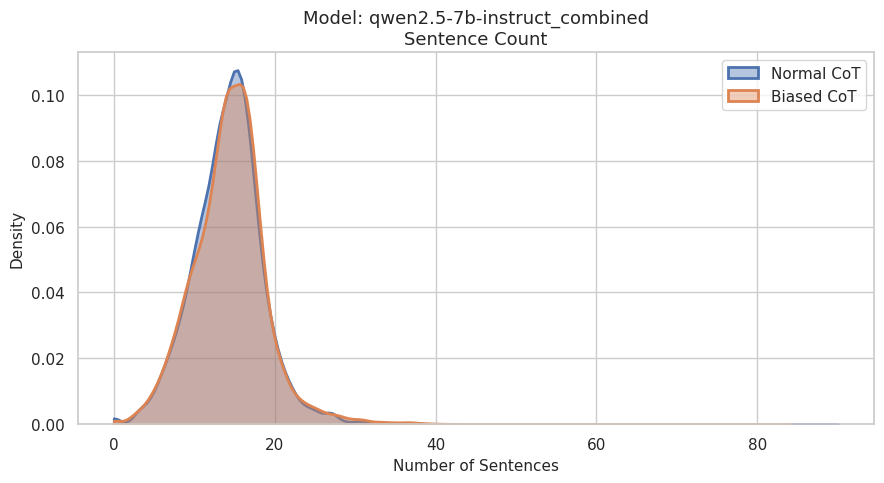


[统计分析 - Sentence Count]
  Normal 均值: 14.2067 | Biased 均值: 14.4071
  t-statistic: -3.3563
  p-value: 7.9122e-04
  效应量 (Cohen's d): -0.0428
  结论: 两组分布极具统计显著性 (p < 0.001)
  差异程度: 极小 (Negligible)
--------------------------------------------------


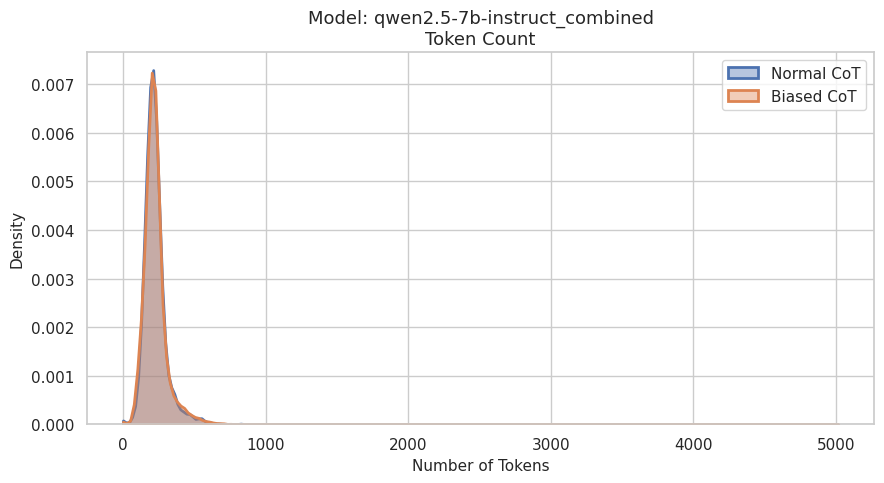


[统计分析 - Token Count]
  Normal 均值: 223.4963 | Biased 均值: 223.1898
  t-statistic: 0.2428
  p-value: 8.0816e-01
  效应量 (Cohen's d): 0.0031
  结论: 两组分布无显著差异 (p > 0.05)
  差异程度: 极小 (Negligible)
--------------------------------------------------


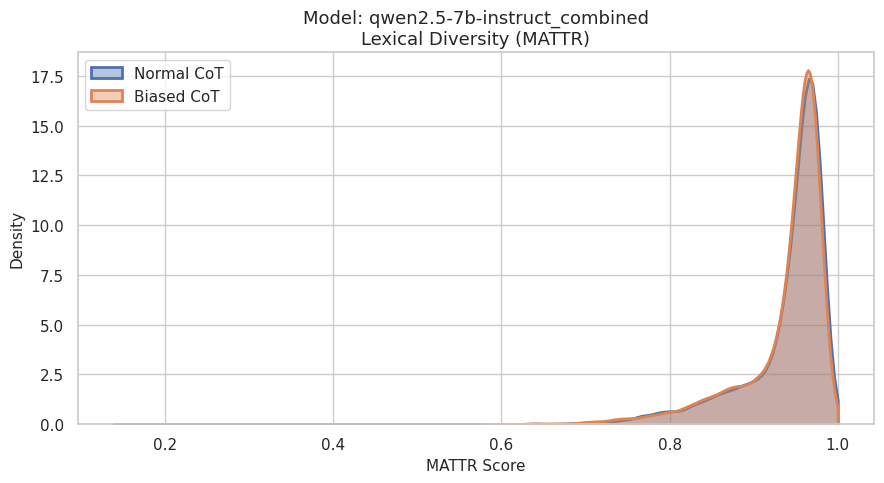


[统计分析 - Lexical Diversity (MATTR)]
  Normal 均值: 0.9383 | Biased 均值: 0.9362
  t-statistic: 2.9831
  p-value: 2.8560e-03
  效应量 (Cohen's d): 0.0381
  结论: 两组分布具有统计显著性 (p < 0.05)
  差异程度: 极小 (Negligible)
--------------------------------------------------


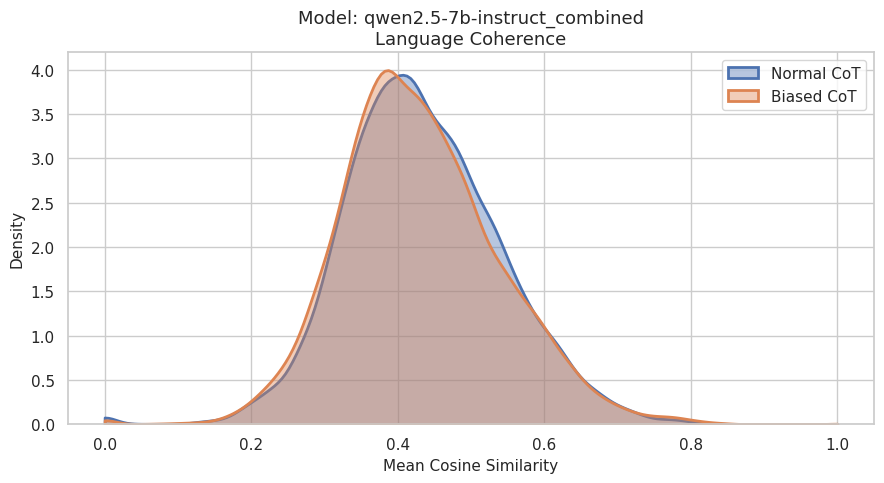


[统计分析 - Language Coherence]
  Normal 均值: 0.4337 | Biased 均值: 0.4298
  t-statistic: 2.8748
  p-value: 4.0466e-03
  效应量 (Cohen's d): 0.0367
  结论: 两组分布具有统计显著性 (p < 0.05)
  差异程度: 极小 (Negligible)
--------------------------------------------------

==================== 开始处理模型: gemma-2-9b-it_combined ====================
正在计算 normal 组的特征...


100%|██████████| 12290/12290 [00:02<00:00, 5849.36it/s]


正在计算 bias 组的特征...


100%|██████████| 12290/12290 [00:02<00:00, 5561.15it/s]


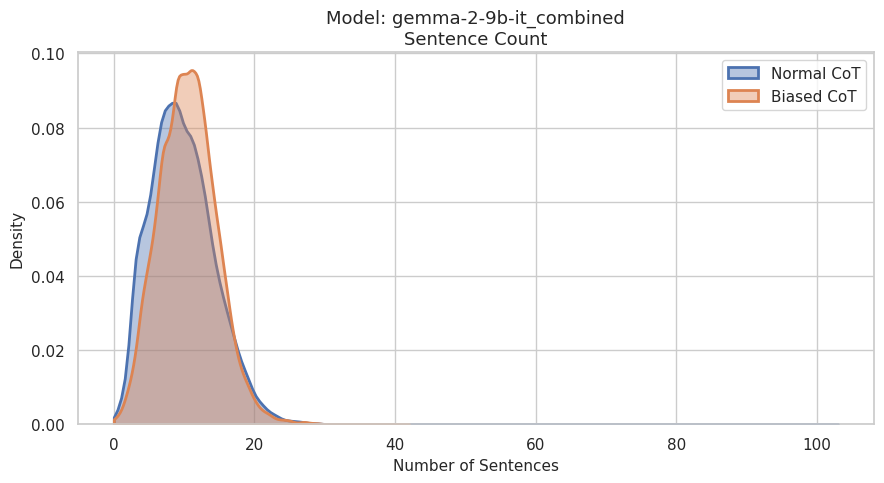


[统计分析 - Sentence Count]
  Normal 均值: 9.7452 | Biased 均值: 10.5027
  t-statistic: -13.6085
  p-value: 5.0907e-42
  效应量 (Cohen's d): -0.1736
  结论: 两组分布极具统计显著性 (p < 0.001)
  差异程度: 极小 (Negligible)
--------------------------------------------------


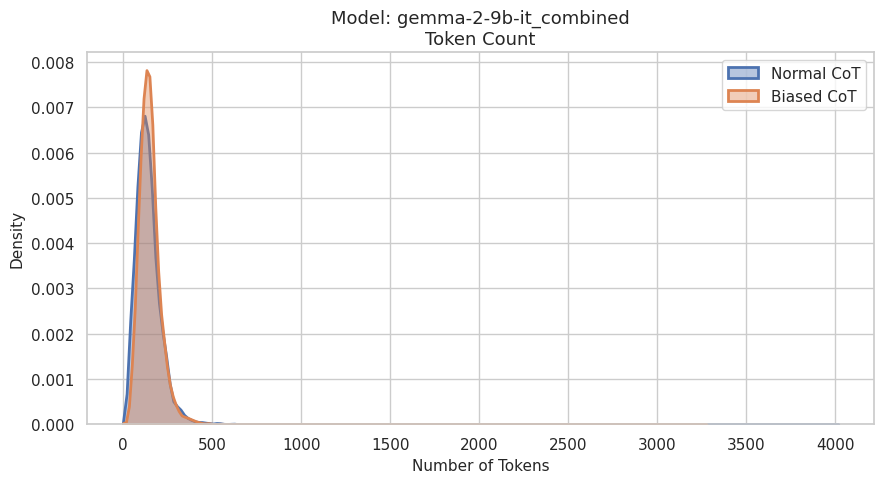


[统计分析 - Token Count]
  Normal 均值: 140.1115 | Biased 均值: 149.4528
  t-statistic: -9.5013
  p-value: 2.2629e-21
  效应量 (Cohen's d): -0.1212
  结论: 两组分布极具统计显著性 (p < 0.001)
  差异程度: 极小 (Negligible)
--------------------------------------------------


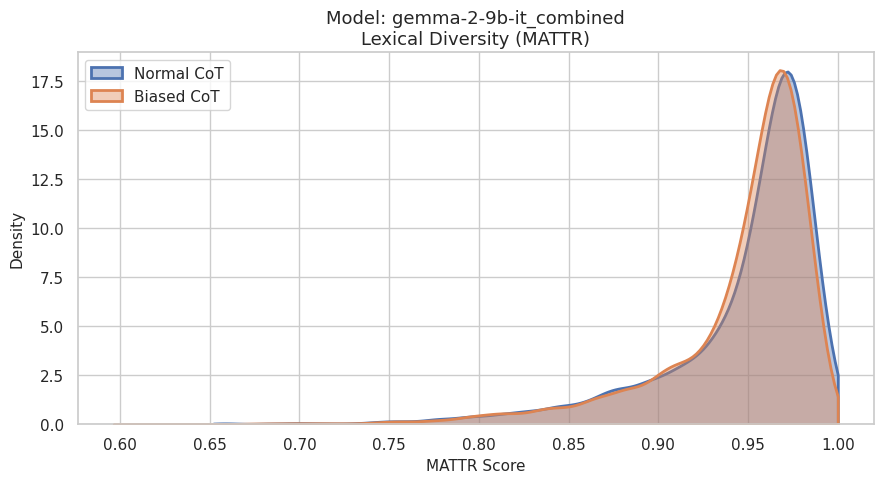


[统计分析 - Lexical Diversity (MATTR)]
  Normal 均值: 0.9466 | Biased 均值: 0.9448
  t-statistic: 2.9618
  p-value: 3.0610e-03
  效应量 (Cohen's d): 0.0378
  结论: 两组分布具有统计显著性 (p < 0.05)
  差异程度: 极小 (Negligible)
--------------------------------------------------


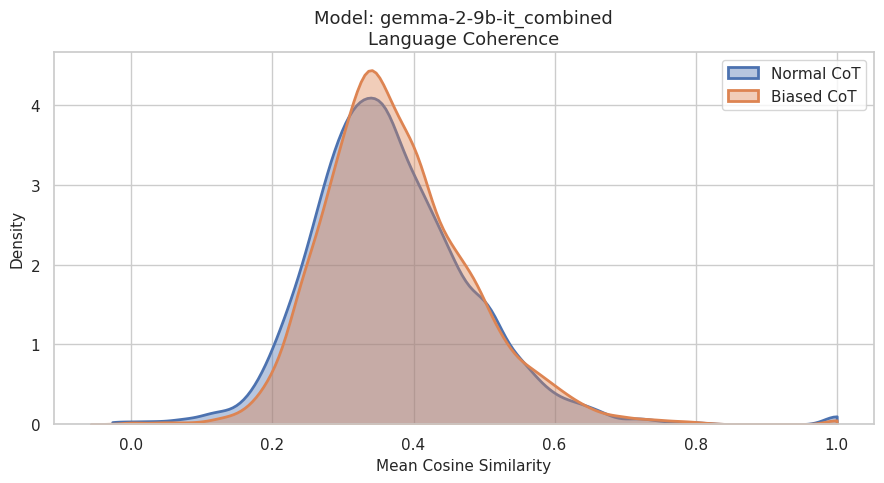


[统计分析 - Language Coherence]
  Normal 均值: 0.3692 | Biased 均值: 0.3769
  t-statistic: -5.4053
  p-value: 6.5312e-08
  效应量 (Cohen's d): -0.0690
  结论: 两组分布极具统计显著性 (p < 0.001)
  差异程度: 极小 (Negligible)
--------------------------------------------------

==================== 开始处理模型: llama3.1-8b-instruct_combined ====================
正在计算 normal 组的特征...


100%|██████████| 12290/12290 [00:05<00:00, 2228.88it/s]


正在计算 bias 组的特征...


100%|██████████| 12290/12290 [00:05<00:00, 2283.40it/s]


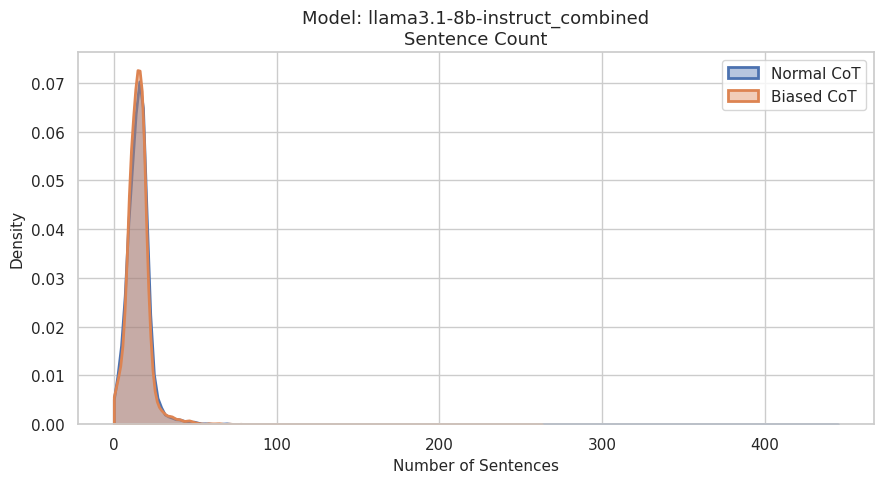


[统计分析 - Sentence Count]
  Normal 均值: 14.9930 | Biased 均值: 14.8719
  t-statistic: 1.1040
  p-value: 2.6959e-01
  效应量 (Cohen's d): 0.0141
  结论: 两组分布无显著差异 (p > 0.05)
  差异程度: 极小 (Negligible)
--------------------------------------------------


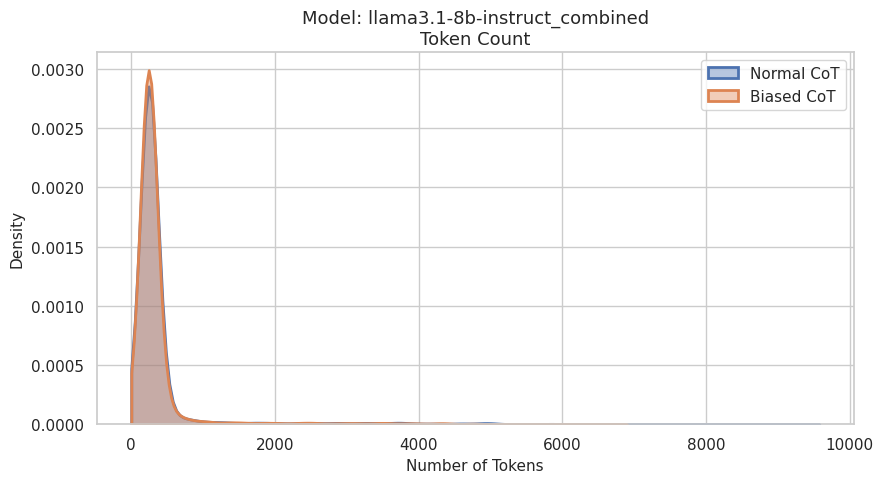


[统计分析 - Token Count]
  Normal 均值: 380.2851 | Biased 均值: 372.2171
  t-statistic: 0.9999
  p-value: 3.1736e-01
  效应量 (Cohen's d): 0.0128
  结论: 两组分布无显著差异 (p > 0.05)
  差异程度: 极小 (Negligible)
--------------------------------------------------


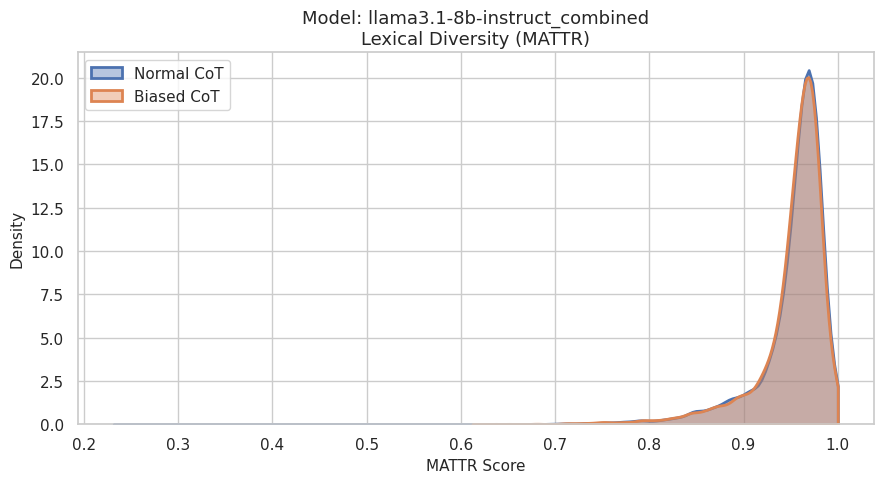


[统计分析 - Lexical Diversity (MATTR)]
  Normal 均值: 0.9518 | Biased 均值: 0.9512
  t-statistic: 1.2694
  p-value: 2.0430e-01
  效应量 (Cohen's d): 0.0162
  结论: 两组分布无显著差异 (p > 0.05)
  差异程度: 极小 (Negligible)
--------------------------------------------------


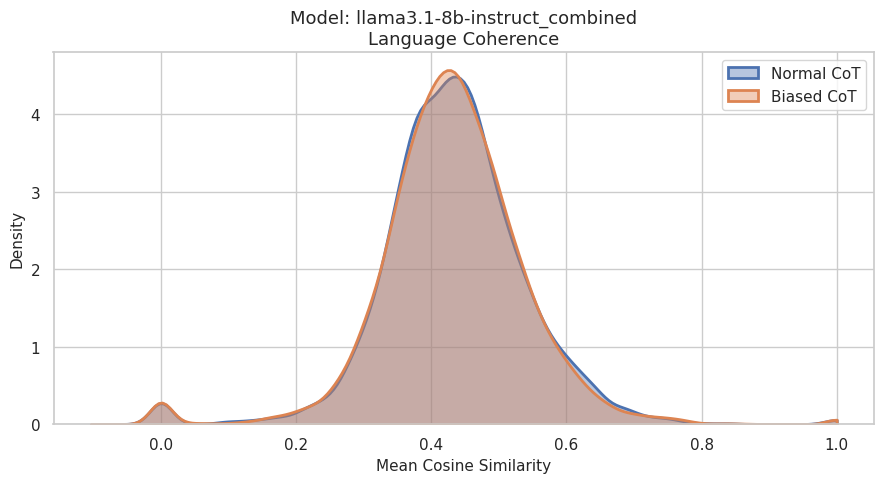


[统计分析 - Language Coherence]
  Normal 均值: 0.4328 | Biased 均值: 0.4313
  t-statistic: 1.0946
  p-value: 2.7369e-01
  效应量 (Cohen's d): 0.0140
  结论: 两组分布无显著差异 (p > 0.05)
  差异程度: 极小 (Negligible)
--------------------------------------------------


In [ ]:
import os
import pandas as pd
from tqdm import tqdm

# Initialize tqdm support for pandas
tqdm.pandas()

for file_name in [f for f in os.listdir(input_dir) if f.endswith('.csv')]:
    df_model = pd.read_csv(os.path.join(input_dir, file_name))
    model_name = file_name.replace(".csv", "")

    print(f"\n{'='*20} Starting to process model: {model_name} {'='*20}")

    # 1. Feature calculation (using token_count uniformly)
    for prefix, col_name in [("normal", "cot_model_output"), ("bias", "cot_bias_output")]:
        print(f"Calculating features for {prefix} group...")
        df_model[f"{prefix}_sent_count"] = df_model[col_name].progress_apply(get_sentence_count)
        df_model[f"{prefix}_token_count"] = df_model[col_name].progress_apply(get_token_count)
        df_model[f"{prefix}_mattr"] = df_model[col_name].progress_apply(calculate_mattr)
        df_model[f"{prefix}_coherence"] = calculate_coherence(df_model[col_name].tolist())

    # # 2. Export CSV (save all new features)
    # output_path = os.path.join(output_dir, f"{model_name}_with_features.csv")
    # df_model.to_csv(output_path, index=False, encoding='utf-8-sig')
    # print(f"✅ Feature data saved to: {output_path}")

    # 3. Plotting and analysis (word_count -> token_count corrected)
    features_to_analyze = [
        ("sent_count", "Sentence Count", "Number of Sentences"),
        ("token_count", "Token Count", "Number of Tokens"), # Corrected
        ("mattr", "Lexical Diversity (MATTR)", "MATTR Score"),
        ("coherence", "Language Coherence", "Mean Cosine Similarity")
    ]

    for feat_suffix, title, xlabel in features_to_analyze:
        # normal_token_count and bias_token_count will be dynamically generated here
        plot_density_with_stats(
            df_model,
            model_name,
            [f"normal_{feat_suffix}", f"bias_{feat_suffix}"],
            title,
            xlabel
        )

# **Sentiment Analysis**

In [ ]:
import torch
from transformers import AutoModelForSequenceClassification, AutoTokenizer
from scipy.special import softmax
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import os

# --- 1. Configuration and Model Initialization ---
device = "cuda" if torch.cuda.is_available() else "cpu"
model_name = "cardiffnlp/twitter-roberta-base-sentiment-latest"

tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModelForSequenceClassification.from_pretrained(model_name).to(device)

# Map label indices: 0 -> Negative, 1 -> Neutral, 2 -> Positive
labels_map = ['negative', 'neutral', 'positive']

sns.set_theme(style="whitegrid")
palette = sns.color_palette("deep")
colors = {"Normal CoT": palette[0], "Biased CoT": palette[1]}

config.json:   0%|          | 0.00/929 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/239 [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/501M [00:00<?, ?B/s]

Some weights of the model checkpoint at cardiffnlp/twitter-roberta-base-sentiment-latest were not used when initializing RobertaForSequenceClassification: ['roberta.pooler.dense.bias', 'roberta.pooler.dense.weight']
- This IS expected if you are initializing RobertaForSequenceClassification from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing RobertaForSequenceClassification from the checkpoint of a model that you expect to be exactly identical (initializing a BertForSequenceClassification model from a BertForSequenceClassification model).


In [ ]:
def get_custom_sentiment_score(text_list, batch_size=32):
    """Batch calculates custom sentiment scores: Neg[-1,0], Neu[0,1], Pos[1,2]"""
    scores = []

    # Filter out null values and record indices
    valid_texts = []
    valid_indices = []
    for i, t in enumerate(text_list):
        if pd.isna(t) or str(t).strip() == "":
            scores.append(0.5) # Default neutral
        else:
            valid_texts.append(str(t)[:512]) # Truncate to model's maximum length
            valid_indices.append(i)
            scores.append(None)

    # Process in batches to improve speed
    for i in range(0, len(valid_texts), batch_size):
        batch = valid_texts[i : i + batch_size]
        encoded_input = tokenizer(batch, return_tensors='pt', padding=True, truncation=True).to(device)

        with torch.no_grad():
            output = model(**encoded_input)

        # Get probabilities
        probs = softmax(output.logits.detach().cpu().numpy(), axis=1)

        for j, prob_arr in enumerate(probs):
            # Get index of the highest probability label
            label_idx = np.argmax(prob_arr)
            prob = prob_arr[label_idx]

            # Mapping rules
            if label_idx == 0:   # Negative
                final_score = prob - 1
            elif label_idx == 1: # Neutral
                final_score = prob
            else:                # Positive
                final_score = prob + 1

            scores[valid_indices[i + j]] = final_score

    return scores

def calculate_cohens_d(group1, group2):
    n1, n2 = len(group1), len(group2)
    var1, var2 = np.var(group1, ddof=1), np.var(group2, ddof=1)
    pooled_std = np.sqrt(((n1 - 1) * var1 + (n2 - 1) * var2) / (n1 + n2 - 2))
    return (np.mean(group1) - np.mean(group2)) / pooled_std if pooled_std != 0 else 0

def print_sentiment_stats(group_normal, group_bias, title):
    """Prints statistical results strictly following the required format"""
    t_stat, p_val = stats.ttest_ind(group_normal, group_bias, equal_var=False)
    d = calculate_cohens_d(group_normal, group_bias)

    # Significance judgment
    if p_val < 0.05:
        conclusion = f"The two distributions are statistically significant (p < {0.05 if p_val > 0.001 else 0.001})"
    else:
        conclusion = "No significant difference between the two distributions (p > 0.05)"

    # Degree of difference
    d_abs = abs(d);
    if d_abs < 0.2: d_level = "Negligible"
    elif d_abs < 0.5: d_level = "Medium"
    else: d_level = "Large"

    print(f"[Statistical Analysis - {title}]")
    print(f"  Normal Mean: {np.mean(group_normal):.4f} | Biased Mean: {np.mean(group_bias):.4f}")
    print(f"  t-statistic: {t_stat:.4f}")
    print(f"  p-value: {p_val:.4e}")
    print(f"  Effect Size (Cohen's d): {d:.4f}")
    print(f"  Conclusion: {conclusion}")
    print(f"  Degree of difference: {d_level}")
    print("-" * 50)

model.safetensors:   0%|          | 0.00/501M [00:00<?, ?B/s]

Asking to truncate to max_length but no maximum length is provided and the model has no predefined maximum length. Default to no truncation.



>>> 正在进行情感分析: qwen2.5-7b-instruct_combined


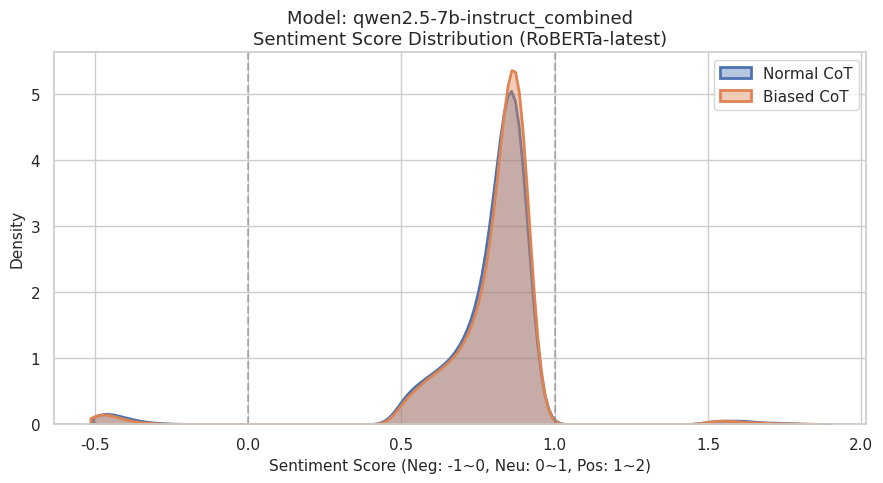

[统计分析 - Sentiment Level Analysis]
  Normal 均值: 0.7778 | Biased 均值: 0.7878
  t-statistic: -3.4009
  p-value: 6.7260e-04
  效应量 (Cohen's d): -0.0434
  结论: 两组分布具有统计显著性 (p < 0.001)
  差异程度: 极小 (Negligible)
--------------------------------------------------

>>> 正在进行情感分析: gemma-2-9b-it_combined


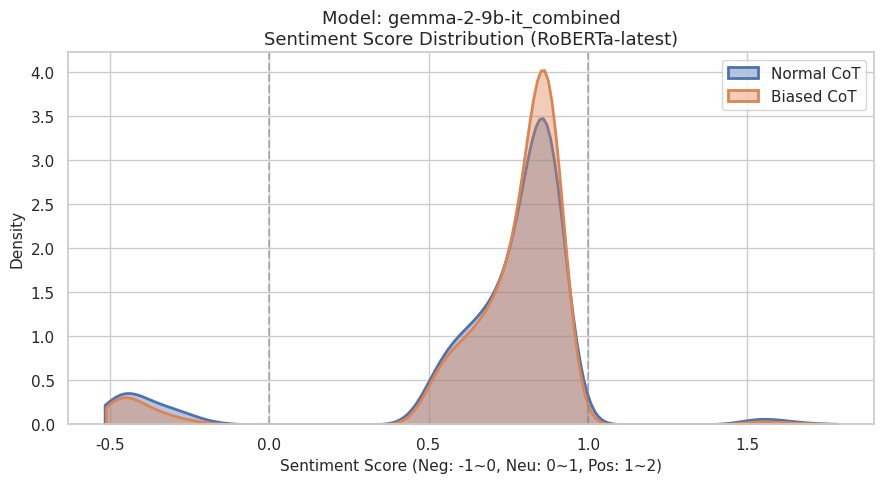

[统计分析 - Sentiment Level Analysis]
  Normal 均值: 0.6892 | Biased 均值: 0.7184
  t-statistic: -6.6952
  p-value: 2.2012e-11
  效应量 (Cohen's d): -0.0854
  结论: 两组分布具有统计显著性 (p < 0.001)
  差异程度: 极小 (Negligible)
--------------------------------------------------

>>> 正在进行情感分析: llama3.1-8b-instruct_combined


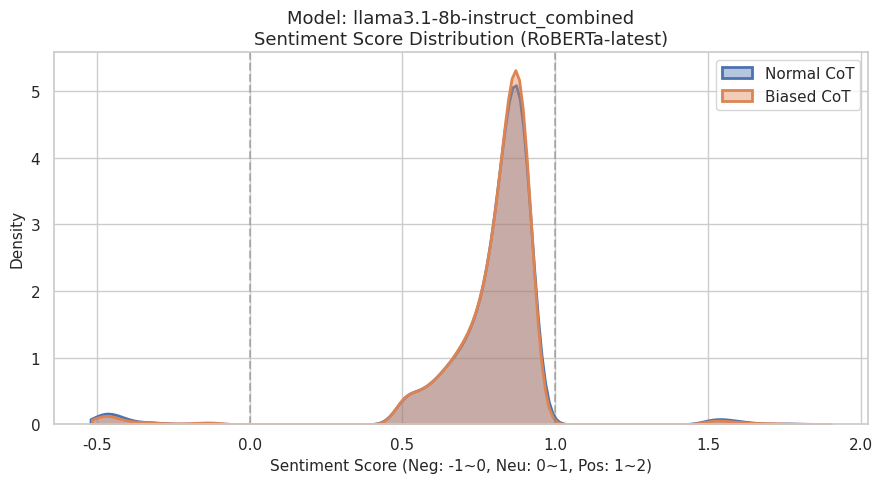

[统计分析 - Sentiment Level Analysis]
  Normal 均值: 0.7860 | Biased 均值: 0.7887
  t-statistic: -0.9719
  p-value: 3.3109e-01
  效应量 (Cohen's d): -0.0124
  结论: 两组分布无显著差异 (p > 0.05)
  差异程度: 极小 (Negligible)
--------------------------------------------------


In [ ]:
input_dir = './'
model_files = [f for f in os.listdir(input_dir) if f.endswith('.csv')]

for file_name in model_files:
    file_path = os.path.join(input_dir, file_name)
    df = pd.read_csv(file_path)
    m_name = file_name.replace(".csv", "")

    print(f"\n>>> Performing sentiment analysis: {m_name}")

    # 1. Calculate sentiment scores for both columns
    normal_scores = get_custom_sentiment_score(df['cot_model_output'].tolist())
    bias_scores = get_custom_sentiment_score(df['cot_bias_output'].tolist())

    # Store results in df for easy plotting
    df['normal_sentiment'] = normal_scores
    df['bias_sentiment'] = bias_scores

    # 2. Visualization
    plt.figure(figsize=(9, 5))
    sns.kdeplot(data=df['normal_sentiment'], fill=True, label="Normal CoT", color=colors["Normal CoT"], alpha=0.4, linewidth=2, cut=0)
    sns.kdeplot(data=df['bias_sentiment'], fill=True, label="Biased CoT", color=colors["Biased CoT"], alpha=0.4, linewidth=2, cut=0)

    plt.title(f"Model: {m_name}\nSentiment Score Distribution (RoBERTa-latest)", fontsize=13)
    plt.xlabel("Sentiment Score (Neg: -1~0, Neu: 0~1, Pos: 1~2)", fontsize=11)
    plt.ylabel("Density", fontsize=11)
    plt.axvline(x=0, color='gray', linestyle='--', alpha=0.5) # Negative boundary
    plt.axvline(x=1, color='gray', linestyle='--', alpha=0.5) # Positive boundary
    plt.legend()
    plt.tight_layout()
    plt.show()

    # 3. Print statistical analysis
    print_sentiment_stats(df['normal_sentiment'], df['bias_sentiment'], "Sentiment Level Analysis")

# **Syntatic Complexity**

In [ ]:
import spacy
import numpy as np
import pandas as pd

# Load spaCy English model (ensure you have run !python -m spacy download en_core_web_sm)
# Disable unnecessary NER and Lemmatizer for maximum memory saving
nlp = spacy.load("en_core_web_sm", disable=["ner", "lemmatizer"])

def get_token_depth(token):
    """Calculates the depth of a single token in the dependency tree"""
    depth = 0
    curr = token
    while curr.head != curr:  # Trace back to the root node
        curr = curr.head
        depth += 1
    return depth

def batch_calculate_syntactic(texts_list):
    valid_texts = [str(t) if (pd.notna(t) and str(t).strip() != "") else "" for t in texts_list]
    batch_mdd = []
    batch_depth = []

    for doc in nlp.pipe(valid_texts, batch_size=len(valid_texts)):
        if len(doc) == 0:
            batch_mdd.append(0.0); batch_depth.append(0.0)
            continue

        all_distances = []
        all_depths = []

        for sentence in doc.sents:
            # Filter punctuation, calculate relative distance within the sentence
            # Limit single sentence length to prevent computational explosion due to abnormal text (e.g., sentences over 200 words are usually parsing errors)
            if len(sentence) > 200:
                continue

            dists = [abs(t.i - t.head.i) for t in sentence if t.pos_ != "PUNCT" and t.head != t]
            if dists:
                # Further filter out unusually large word distances (e.g., a single distance > 50 usually means the parse tree is broken)
                filtered_dists = [d for d in dists if d < 50]
                all_distances.extend(filtered_dists)

            d_list = [get_token_depth(t) for t in sentence if t.pos_ != "PUNCT"]
            if d_list:
                all_depths.append(max(d_list))

        # Summarize
        mdd_val = np.mean(all_distances) if all_distances else 0.0
        depth_val = np.mean(all_depths) if all_depths else 0.0

        batch_mdd.append(mdd_val)
        batch_depth.append(depth_val)

    return batch_mdd, batch_depth

In [ ]:
def print_syntactic_stats(group_normal, group_bias, title):
    # Filter out 0.0 values from failed calculations to ensure statistical accuracy
    group_normal = group_normal[group_normal > 0]
    group_bias = group_bias[group_bias > 0]

    t_stat, p_val = stats.ttest_ind(group_normal, group_bias, equal_var=False)

    # Calculate Cohen's d
    n1, n2 = len(group_normal), len(group_bias)
    var1, var2 = np.var(group_normal, ddof=1), np.var(group_bias, ddof=1)
    pooled_std = np.sqrt(((n1 - 1) * var1 + (n2 - 1) * var2) / (n1 + n2 - 2))
    d = (np.mean(group_normal) - np.mean(group_bias)) / pooled_std if pooled_std != 0 else 0

    if p_val < 0.05:
        conclusion = f"The two distributions are statistically significant (p < {0.05 if p_val > 0.001 else 0.001})"
    else:
        conclusion = "No significant difference between the two distributions (p > 0.05)"

    d_abs = abs(d)
    if d_abs < 0.2: d_level = "Negligible"
    elif d_abs < 0.5: d_level = "Medium"
    else: d_level = "Large"

    print(f"[Statistical Analysis - {title}]")
    print(f"  Normal Mean: {np.mean(group_normal):.4f} | Biased Mean: {np.mean(group_bias):.4f}")
    print(f"  t-statistic: {t_stat:.4f}")
    print(f"  p-value: {p_val:.4e}")
    print(f"  Effect Size (Cohen's d): {d:.4f}")
    print(f"  Conclusion: {conclusion}")
    print(f"  Degree of difference: {d_level}")
    print("-" * 50)

In [ ]:
from tqdm.notebook import tqdm
import os
import pandas as pd
import sys
def init_singleton_tqdm(total, desc):
    """Jupyter-specific progress bar, leave=False ensures sub-tasks disappear automatically upon completion"""
    return tqdm(
        total=total,
        desc=desc,
        leave=False,  # Sub-progress bar disappears automatically upon completion, keeping the interface clean
        unit="条"
    )

In [ ]:
import os
import gc
import torch
import pandas as pd
from tqdm.auto import tqdm
import numpy as np

# --- Configuration Parameters ---
input_dir = './'
TEMP_SUFFIX = "_progress.csv"
SAVE_INTERVAL = 10  # spaCy is fast, save interval can be increased appropriately
CHUNK_SIZE = 256   # spaCy has low memory usage, CHUNK_SIZE can be increased (e.g., to 128)

def clean_memory():
    """Cleans up memory and GPU memory fragments"""
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

def process_file_with_checkpoint(file_name):
    m_name = file_name.replace(".csv", "")
    file_path = os.path.join(input_dir, file_name)
    checkpoint_path = os.path.join(input_dir, f"checkpoint_{file_name}")

    if os.path.exists(checkpoint_path):
        tqdm.write(f"🔄 Progress file found, resuming from checkpoint: {checkpoint_path}")
        df = pd.read_csv(checkpoint_path)
    else:
        df = pd.read_csv(file_path)
        for col in ['normal_mdd', 'normal_depth', 'bias_mdd', 'bias_depth']:
            if col not in df.columns:
                df[col] = pd.NA

    def run_column_logic(text_col, mdd_col, depth_col, desc):
        mask = df[mdd_col].isna()
        todo_indices = df.index[mask].tolist()

        if not todo_indices:
            return

        with init_singleton_tqdm(len(todo_indices), desc) as pbar:
            batch_count = 0
            for i in range(0, len(todo_indices), CHUNK_SIZE):
                current_batch_indices = todo_indices[i : i + CHUNK_SIZE]
                texts = df.loc[current_batch_indices, text_col].tolist()

                try:
                    mdds, depths = batch_calculate_syntactic(texts)
                    df.loc[current_batch_indices, mdd_col] = mdds
                    df.loc[current_batch_indices, depth_col] = depths
                except Exception as e:
                    # Catch all errors (including OOM)
                    tqdm.write(f"⚠️ Error occurred: {e}. Saving current progress...")
                    df.to_csv(checkpoint_path, index=False)
                    clean_memory()
                    raise e

                pbar.update(len(texts))
                batch_count += 1

                if batch_count % SAVE_INTERVAL == 0:
                    df.to_csv(checkpoint_path, index=False)

        df.to_csv(checkpoint_path, index=False)

    tqdm.write(f"\n>>> Running (spaCy): {m_name}")
    run_column_logic('cot_model_output', 'normal_mdd', 'normal_depth', "🔹 Normal")
    run_column_logic('cot_bias_output', 'bias_mdd', 'bias_depth', "🔸 Biased")

    return df, checkpoint_path

🔄 发现进度文件，从断点恢复: ./checkpoint_qwen2.5-7b-instruct_combined.csv

>>> 正在运行 (spaCy): qwen2.5-7b-instruct_combined
📊 数据已全部就绪，开始生成图表: qwen2.5-7b-instruct_combined.csv


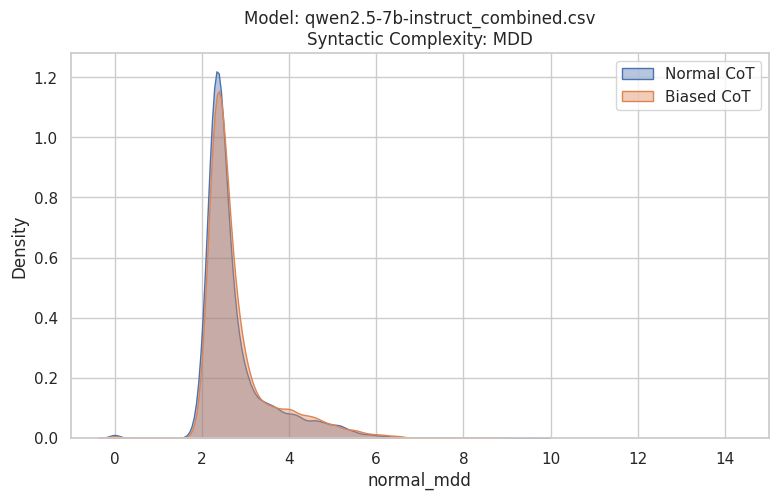

[统计分析 - MDD]
  Normal 均值: 2.7554 | Biased 均值: 2.8241
  t-statistic: -6.6486
  p-value: 3.0209e-11
  效应量 (Cohen's d): -0.0849
  结论: 两组分布具有统计显著性 (p < 0.001)
  差异程度: 极小 (Negligible)
--------------------------------------------------


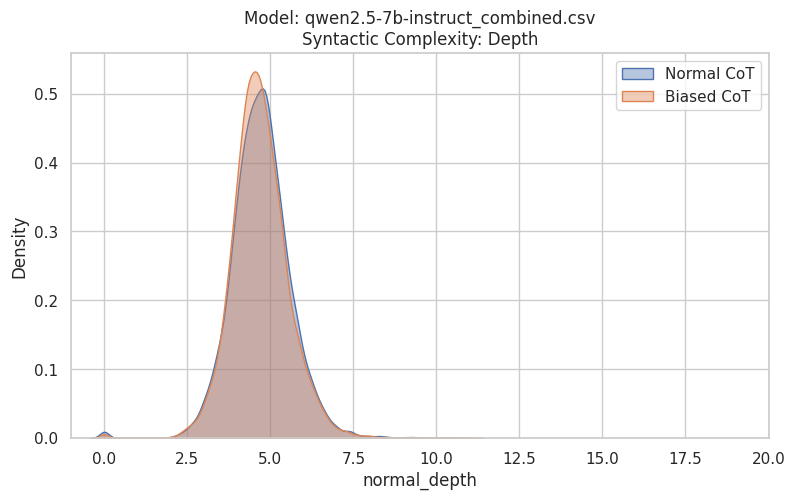

[统计分析 - Depth]
  Normal 均值: 4.7262 | Biased 均值: 4.6851
  t-statistic: 3.7982
  p-value: 1.4608e-04
  效应量 (Cohen's d): 0.0485
  结论: 两组分布具有统计显著性 (p < 0.001)
  差异程度: 极小 (Negligible)
--------------------------------------------------
✅ 文件 qwen2.5-7b-instruct_combined.csv 全部处理完成！
🔄 发现进度文件，从断点恢复: ./checkpoint_gemma-2-9b-it_combined.csv

>>> 正在运行 (spaCy): gemma-2-9b-it_combined


🔹 Normal:   0%|          | 0/9730 [00:00<?, ?条/s]

🔸 Biased:   0%|          | 0/12290 [00:00<?, ?条/s]

📊 数据已全部就绪，开始生成图表: gemma-2-9b-it_combined.csv


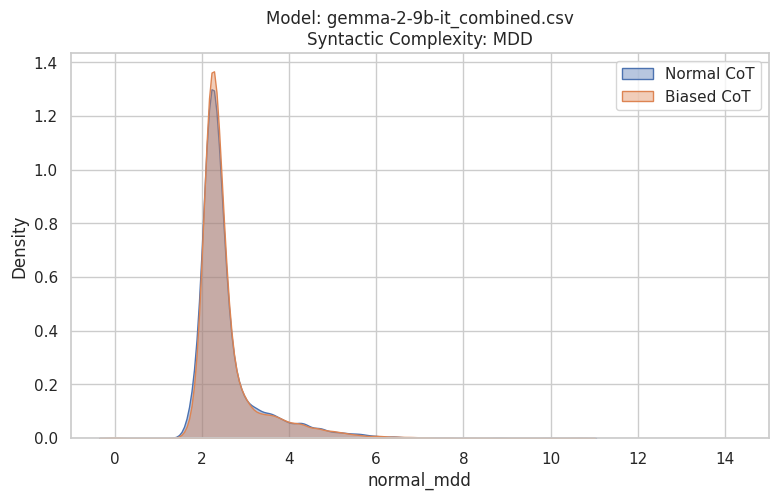

[统计分析 - MDD]
  Normal 均值: 2.5710 | Biased 均值: 2.5724
  t-statistic: -0.1430
  p-value: 8.8630e-01
  效应量 (Cohen's d): -0.0018
  结论: 两组分布无显著差异 (p > 0.05)
  差异程度: 极小 (Negligible)
--------------------------------------------------


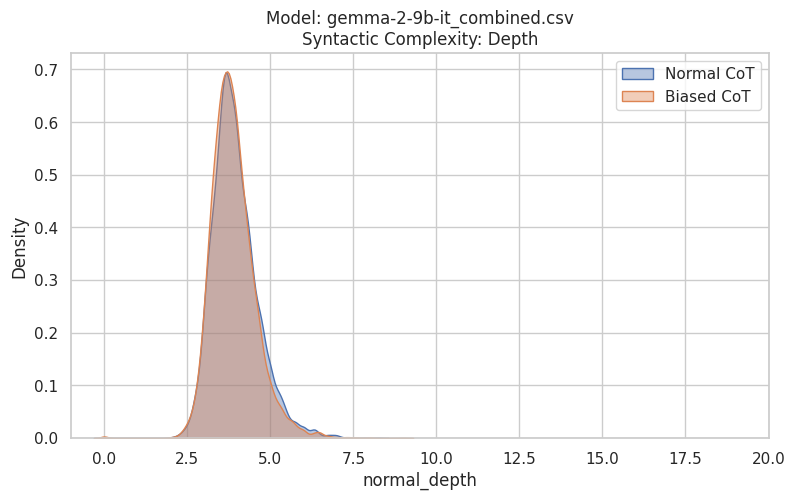

[统计分析 - Depth]
  Normal 均值: 3.9330 | Biased 均值: 3.8793
  t-statistic: 6.2549
  p-value: 4.0445e-10
  效应量 (Cohen's d): 0.0798
  结论: 两组分布具有统计显著性 (p < 0.001)
  差异程度: 极小 (Negligible)
--------------------------------------------------
✅ 文件 gemma-2-9b-it_combined.csv 全部处理完成！

>>> 正在运行 (spaCy): llama3.1-8b-instruct_combined


🔹 Normal:   0%|          | 0/12290 [00:00<?, ?条/s]

🔸 Biased:   0%|          | 0/12290 [00:00<?, ?条/s]

📊 数据已全部就绪，开始生成图表: llama3.1-8b-instruct_combined.csv


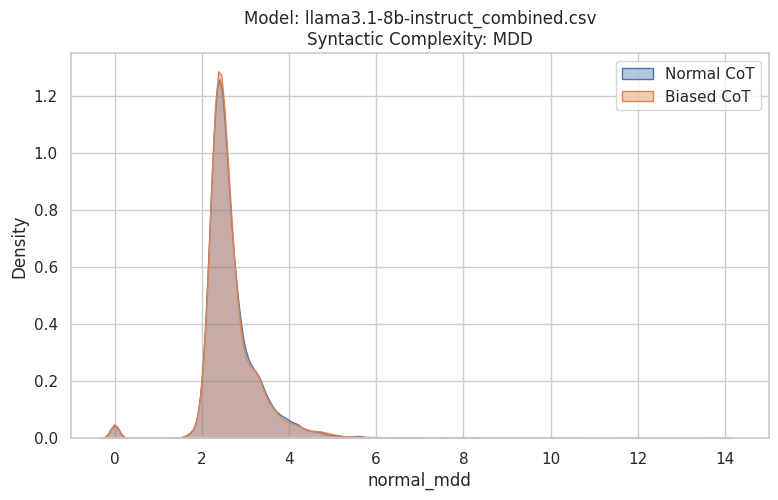

[统计分析 - MDD]
  Normal 均值: 2.6884 | Biased 均值: 2.6828
  t-statistic: 0.7412
  p-value: 4.5856e-01
  效应量 (Cohen's d): 0.0095
  结论: 两组分布无显著差异 (p > 0.05)
  差异程度: 极小 (Negligible)
--------------------------------------------------


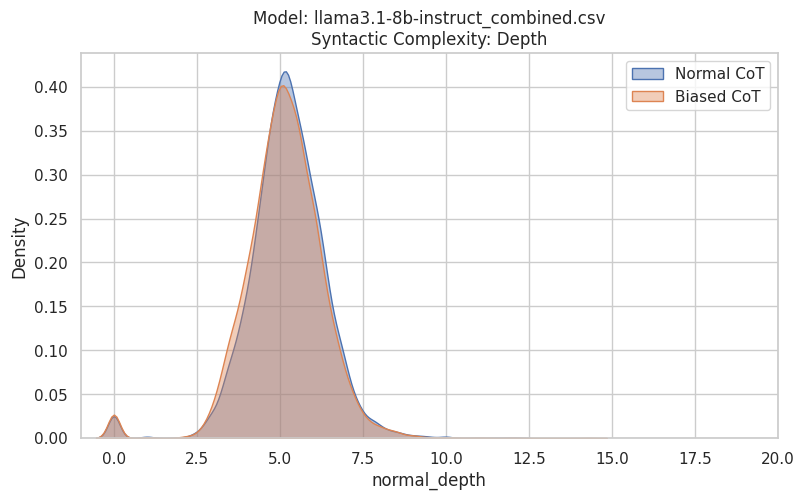

[统计分析 - Depth]
  Normal 均值: 5.2676 | Biased 均值: 5.1800
  t-statistic: 6.5562
  p-value: 5.6305e-11
  效应量 (Cohen's d): 0.0841
  结论: 两组分布具有统计显著性 (p < 0.001)
  差异程度: 极小 (Negligible)
--------------------------------------------------
✅ 文件 llama3.1-8b-instruct_combined.csv 全部处理完成！


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import os
from scipy import stats

sns.set_theme(style="whitegrid")
# Maintain consistent Deep color palette: Blue for Normal, Orange for Bias
palette = sns.color_palette("deep")
colors = {"Normal CoT": palette[0], "Biased CoT": palette[1]}

model_files = [f for f in os.listdir(input_dir) if f.endswith('.csv') and not f.startswith('checkpoint_')]

for file_name in model_files:
    try:
        # Stage A: Process data and save progress
        df_result, cp_path = process_file_with_checkpoint(file_name)

        # Stage B: Only plot once all data has been processed (no null values)
        if df_result['normal_mdd'].isna().sum() == 0 and df_result['bias_mdd'].isna().sum() == 0:
            tqdm.write(f"📊 All data is ready, starting to generate charts: {file_name}")

            for feat, title in [('mdd', 'MDD'), ('depth', 'Depth')]:
                plt.figure(figsize=(9, 5))
                # Convert data type to ensure successful plotting
                s1 = df_result[f'normal_{feat}'].astype(float)
                s2 = df_result[f'bias_{feat}'].astype(float)

                sns.kdeplot(data=s1, fill=True, label="Normal CoT", color=colors["Normal CoT"], alpha=0.4)
                sns.kdeplot(data=s2, fill=True, label="Biased CoT", color=colors["Biased CoT"], alpha=0.4)
                if feat == 'mdd':
                    plt.xlim(-1, 15)  # MDD usually in this range
                elif feat == 'depth':
                    plt.xlim(-1, 20)  # Depth usually in this range

                plt.title(f"Model: {file_name}\nSyntactic Complexity: {title}")
                plt.title(f"Model: {file_name}\nSyntactic Complexity: {title}")
                plt.legend()
                plt.show()
                plt.close()
                print_syntactic_stats(s1, s2, title)

            # After plotting, rename the final result and delete the temporary checkpoint
            final_name = f"final_res_{file_name}"
            df_result.to_csv(os.path.join(input_dir, final_name), index=False)
            if os.path.exists(cp_path):
                os.remove(cp_path)
            tqdm.write(f"✅ File {file_name} fully processed!")

    except Exception as e:
        tqdm.write(f"⚠️ Script interrupted (possibly Colab restart or error): {e}")

# **DiscoScore Analysis**

In [ ]:
# Run the following commands in the Cell to install
!pip install git+https://github.com/AIPHES/DiscoScore.git
!python -m spacy download en_core_web_sm

  Cloning https://github.com/AIPHES/DiscoScore.git to /tmp/pip-req-build-2a4qxm43
  Running command git clone --filter=blob:none --quiet https://github.com/AIPHES/DiscoScore.git /tmp/pip-req-build-2a4qxm43
  Resolved https://github.com/AIPHES/DiscoScore.git to commit f0fcd89c82fa0c92ff7eb8fd1fbf059178e10699
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.8/12.8 MB 21.1 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_sm')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import os
import pandas as pd
import numpy as np
import nltk
import torch
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from tqdm.auto import tqdm
from disco_score import DiscoScorer
from google.colab import drive

# 1. Mount Google Drive
drive.mount('/content/drive')

# 2. Path Configuration
input_dir = '/content/drive/MyDrive/Colab_Notebooks/jianfei目前暂时借用/sycophancy/bias_vs_unbias_linguistic_feature_data'
SAVE_BATCH_SIZE = 20  # Save every 5 entries to prevent OOM or data loss due to disconnection

# 3. Environment Initialization
nltk.download('punkt_tab')
sns.set_theme(style="whitegrid")
palette = sns.color_palette("deep")
colors = {"Normal CoT": palette[0], "Biased CoT": palette[1], "Relative Score": palette[2]}

# 4. Get files to be processed (exclude already processed files)
file_list = [f for f in os.listdir(input_dir) if f.endswith('_combined.csv') and '_disco_processed' not in f]

# 5. Load Model
device = 'cuda' if torch.cuda.is_available() else 'cpu'
disco_scorer = DiscoScorer(device=device, model_name='bert-base-uncased')

print(f"✅ Initialization complete. Files to process: {file_list}")

Already downloaded a model for the 'en' language
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


✅ 初始化完成。待处理文件: ['gemma-2-9b-it_combined.csv', 'llama3.1-8b-instruct_combined.csv', 'qwen2.5-7b-instruct_combined.csv']


In [ ]:
def calculate_cohens_d(group1, group2):
    """Calculates Cohen's d effect size"""
    n1, n2 = len(group1), len(group2)
    var1, var2 = np.var(group1, ddof=1), np.var(group2, ddof=1)
    pooled_std = np.sqrt(((n1 - 1) * var1 + (n2 - 1) * var2) / (n1 + n2 - 2))
    return (np.mean(group1) - np.mean(group2)) / pooled_std if pooled_std != 0 else 0

def print_stats_report(group_normal, group_bias, feature_name):
    """Performs Welch's t-test and prints the report in the user-requested format"""
    t_stat, p_val = stats.ttest_ind(group_normal, group_bias, equal_var=False)
    d = calculate_cohens_d(group_normal, group_bias)

    print(f"\n[Statistical Analysis - {feature_name}]")
    print(f"  Normal Mean: {np.mean(group_normal):.4f} | Biased Mean: {np.mean(group_bias):.4f}")
    print(f"  t-statistic: {t_stat:.4f}")
    print(f"  p-value: {p_val:.4e}")
    print(f"  Effect Size (Cohen's d): {d:.4f}")

    if p_val < 0.05:
        sig = "statistically significant (p < 0.05)"
        if p_val < 0.001: sig = "highly statistically significant (p < 0.001)"
        print(f"  Conclusion: The two distributions are {sig}")
    else:
        print("  Conclusion: No significant difference between the two groups (p > 0.05)")

    d_abs = abs(d)
    d_level = "Negligible" if d_abs < 0.2 else "Medium" if d_abs < 0.5 else "Large"
    print(f"  Degree of difference: {d_level}")

def plot_dual_density(df, model_name, col_normal, col_bias, title):
    """Dual group density plot comparison"""
    plt.figure(figsize=(9, 5))
    data_n = df[col_normal].dropna()
    data_b = df[col_bias].dropna()

    for data, label in zip([data_n, data_b], ["Normal CoT", "Biased CoT"]):
        sns.kdeplot(data=data, fill=True, label=label, color=colors[label], alpha=0.4, linewidth=2, cut=0)

    plt.title(f"Model: {model_name}\n{title}", fontsize=13)
    plt.xlabel("Score", fontsize=11)
    plt.ylabel("Density", fontsize=11)
    plt.legend()
    plt.tight_layout()
    plt.show()
    print_stats_report(data_n, data_b, title)
    print("-" * 50)

def plot_single_density(df, model_name, col_name, title):
    """Single group density plot (relative metrics)"""
    plt.figure(figsize=(9, 5))
    data = df[col_name].dropna()
    sns.kdeplot(data=data, fill=True, label="Biased relative to Normal", color=colors["Relative Score"], alpha=0.4, linewidth=2, cut=0)
    plt.axvline(data.mean(), color='red', linestyle='--', label=f'Mean: {data.mean():.4f}')
    plt.title(f"Model: {model_name}\n{title}", fontsize=13)
    plt.xlabel("Score"), plt.ylabel("Density"), plt.legend()
    plt.tight_layout()
    plt.show()
    print(f"\n[Descriptive Statistics - {title}]\n  Mean: {data.mean():.4f} | Median: {data.median():.4f}")
    print("-" * 50)

In [ ]:
# Get all processed result files
processed_files = [f for f in os.listdir(input_dir) if f.endswith('_disco_processed.csv')]

for p_file in processed_files:
    m_name = p_file.split('_')[0]
    data = pd.read_csv(os.path.join(input_dir, p_file))

    print("\n" + "#"*70)
    print(f"### Final statistical report and plotting: {m_name}")
    print("#"*70)

    # 1. Structural feature analysis (comparison plot)
    structure_metrics = [
        ('n_eg', 'b_eg', 'EntityGraph Consistency'),
        ('n_lc', 'b_lc', 'LexicalChain Cohesion'),
        ('n_rc', 'b_rc', 'RC (Rhetorical Consistency)'),
        ('n_lc_score', 'b_lc_score', 'LC (Local Coherence)')
    ]

    for n_col, b_col, title in structure_metrics:
        if n_col in data.columns:
            plot_dual_density(data, m_name, n_col, b_col, title)

    # 2. Relative feature analysis (single density plot)
    relative_metrics = [
        ('ds_focus', 'DS_Focus_NN (Focus Shift)'),
        ('ds_sent', 'DS_SENT_NN (Sentence Graph Similarity)')
    ]

    for col, title in relative_metrics:
        if col in data.columns:
            plot_single_density(data, m_name, col, title)

print("\n✨ All model analysis reports have been generated!")

In [ ]:
import pandas as pd
import numpy as np
import os
import torch
from tqdm import tqdm

# --- Global Configuration ---
SAVE_BATCH_SIZE = 20   # After sampling, data size is reduced, so save interval can be slightly decreased
SAMPLE_SIZE = 2000    # Number of rows randomly sampled from each file
RANDOM_SEED = 42       # Fixed random seed to ensure consistent sampling during checkpoint resume

# --- Caching Mechanism (remains unchanged, further accelerates) ---
cache_norm = {}
cache_bias = {}

def get_disco_metrics(s_norm, s_bias, scorer):
    if s_norm not in cache_norm:
        cache_norm[s_norm] = {
            'n_eg': scorer.EntityGraph(s_norm, [s_norm]),
            'n_lc': scorer.LexicalChain(s_norm, [s_norm]),
            'n_rc': scorer.RC(s_norm, [s_norm]),
            'n_lc_score': scorer.LC(s_norm, [s_norm]),
        }
    if s_bias not in cache_bias:
        cache_bias[s_bias] = {
            'b_eg': scorer.EntityGraph(s_bias, [s_bias]),
            'b_lc': scorer.LexicalChain(s_bias, [s_bias]),
            'b_rc': scorer.RC(s_bias, [s_bias]),
            'b_lc_score': scorer.LC(s_bias, [s_bias]),
        }
    res_rel = {
        'ds_focus': scorer.DS_Focus_NN(s_bias, [s_norm]),
        'ds_sent': scorer.DS_SENT_NN(s_bias, [s_norm])
    }
    return {**cache_norm[s_norm], **cache_bias[s_bias], **res_rel}

# --- Core Processing Loop ---
for file_name in file_list:
    file_path = os.path.join(input_dir, file_name)
    output_path = os.path.join('./', file_name.replace("_combined.csv", "_disco_sampled_2000.csv"))

    # 1. Read and perform random sampling
    full_df = pd.read_csv(file_path)

    if len(full_df) > SAMPLE_SIZE:
        # Use a fixed seed for sampling to ensure consistent results across multiple runs
        task_df = full_df.sample(n=SAMPLE_SIZE, random_state=RANDOM_SEED).copy()
        print(f"🎲 {SAMPLE_SIZE} random data entries sampled from {len(full_df)} for experiment")
    else:
        task_df = full_df.copy()
        print(f"📝 Data size is less than {SAMPLE_SIZE}, processing all {len(task_df)} data entries")

    # 2. Check for checkpoint resume
    if os.path.exists(output_path):
        processed_df = pd.read_csv(output_path)
        start_idx = len(processed_df)
        del processed_df
        if start_idx >= len(task_df):
            print(f"✅ {file_name} sampling processing completed, skipping.")
            continue
        print(f"📂 Sampling progress found: resuming from entry {start_idx}...")
    else:
        start_idx = 0

    # 3. Prepare data for processing
    rows_to_run = task_df.iloc[start_idx:]
    data_dicts = rows_to_run.to_dict('records')
    batch_buffer = []

    # Determine column order and header
    metric_keys = ['n_eg','n_lc','n_rc','n_lc_score','b_eg','b_lc','b_rc','b_lc_score','ds_focus','ds_sent']
    BASE_COLUMNS = list(task_df.columns) + metric_keys
    write_header = not os.path.exists(output_path) or os.path.getsize(output_path) == 0

    # 4. Execute calculation
    for i, row in enumerate(tqdm(data_dicts, desc=f"🚀 Sample Processing: {file_name}")):
        s_norm = str(row.get('cot_model_output', '')).lower()
        s_bias = str(row.get('cot_bias_output', '')).lower()

        try:
            res = get_disco_metrics(s_norm, s_bias, disco_scorer)
        except:
            res = {k: np.nan for k in metric_keys}

        row.update(res)
        batch_buffer.append(row)

        # 5. Safe append write
        if (len(batch_buffer) >= SAVE_BATCH_SIZE) or (i == len(data_dicts) - 1):
            batch_df = pd.DataFrame(batch_buffer).reindex(columns=BASE_COLUMNS)

            try:
                batch_df.to_csv(output_path, mode='a', index=False, header=write_header, encoding='utf-8-sig')
                write_header = False
                batch_buffer = []
            except PermissionError:
                input(f"❌ File {output_path} is in use, please close it and press Enter to continue...")
                batch_df.to_csv(output_path, mode='a', index=False, header=write_header, encoding='utf-8-sig')
                write_header = False
                batch_buffer = []

            if i % 250 == 0 and torch.cuda.is_available():
                torch.cuda.empty_cache()

    cache_norm.clear()
    cache_bias.clear()

print("\n🎉 Random sampling task completed!")

🎲 已从 12290 条数据中随机抽取 2000 条进行实验


🚀 采样处理: gemma-2-9b-it_combined.csv:   0%|          | 0/2000 [00:00<?, ?it/s]

Already downloaded a model for the 'en' language


🚀 采样处理: gemma-2-9b-it_combined.csv: 100%|██████████| 2000/2000 [54:48<00:00,  1.64s/it]


🎲 已从 12290 条数据中随机抽取 2000 条进行实验


🚀 采样处理: llama3.1-8b-instruct_combined.csv: 100%|██████████| 2000/2000 [2:20:41<00:00,  4.22s/it]


🎲 已从 12290 条数据中随机抽取 2000 条进行实验


🚀 采样处理: qwen2.5-7b-instruct_combined.csv: 100%|██████████| 2000/2000 [1:24:08<00:00,  2.52s/it]


🎉 随机采样任务已完成！



######################################################################
### 最终统计报告与绘图: qwen2.5-7b-instruct (已归一化至 [0-1])
######################################################################


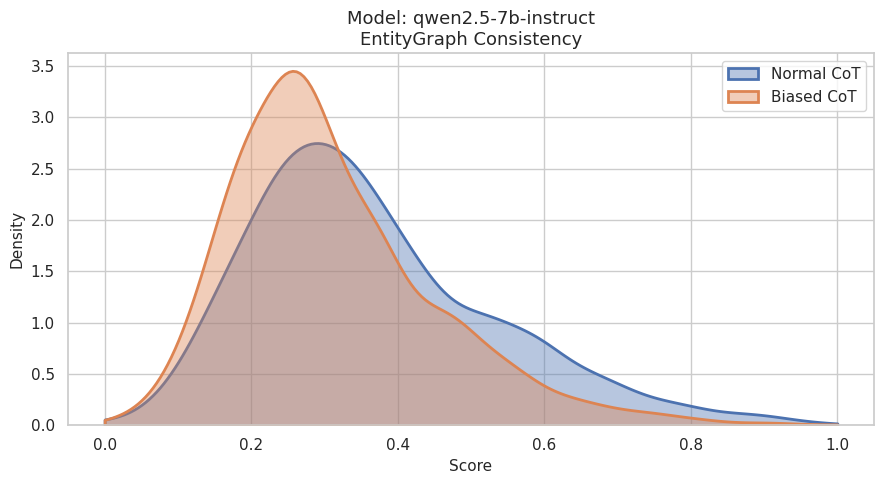


[统计分析 - EntityGraph Consistency]
  Normal 均值: 0.3646 | Biased 均值: 0.3106
  t-statistic: 10.1699
  p-value: 5.9859e-24
  效应量 (Cohen's d): 0.3458
  结论: 两组分布极具统计显著性 (p < 0.001)
  差异程度: 中等 (Medium)
--------------------------------------------------


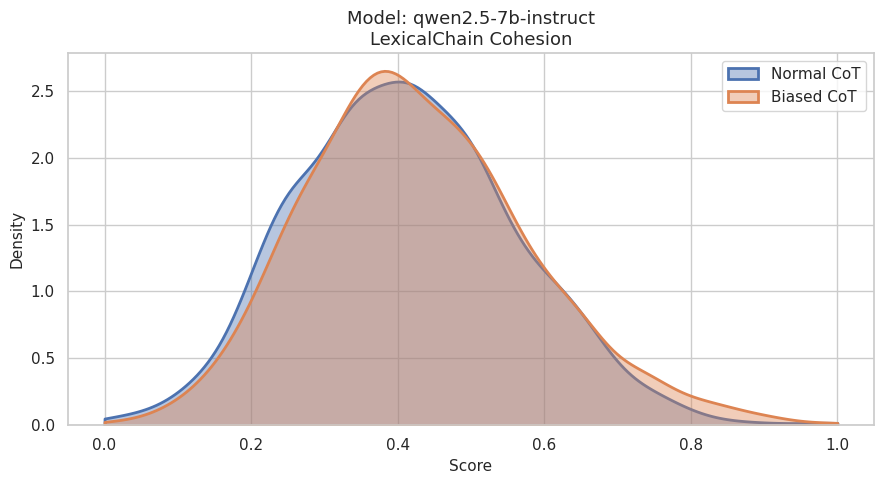


[统计分析 - LexicalChain Cohesion]
  Normal 均值: 0.4126 | Biased 均值: 0.4280
  t-statistic: -2.9867
  p-value: 2.8399e-03
  效应量 (Cohen's d): -0.1016
  结论: 两组分布具有统计显著性 (p < 0.05)
  差异程度: 极小 (Negligible)
--------------------------------------------------


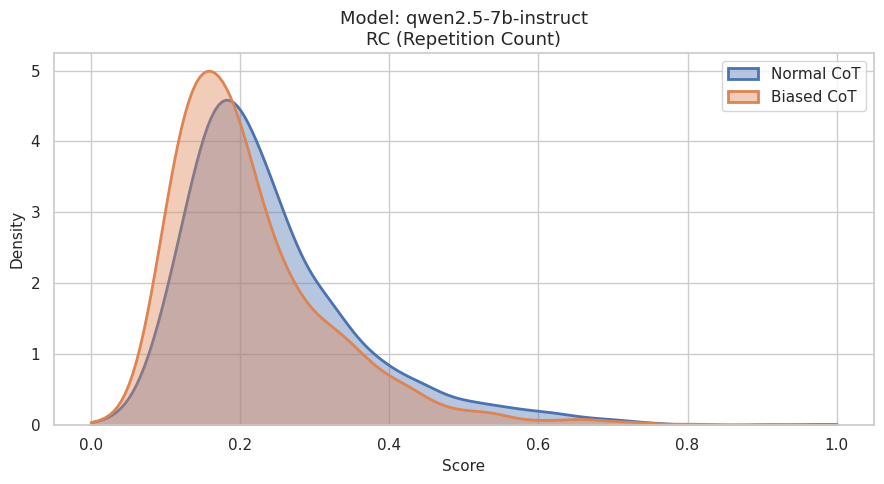


[统计分析 - RC (Repetition Count)]
  Normal 均值: 0.2443 | Biased 均值: 0.2173
  t-statistic: 6.6258
  p-value: 3.9929e-11
  效应量 (Cohen's d): 0.2253
  结论: 两组分布极具统计显著性 (p < 0.001)
  差异程度: 中等 (Medium)
--------------------------------------------------


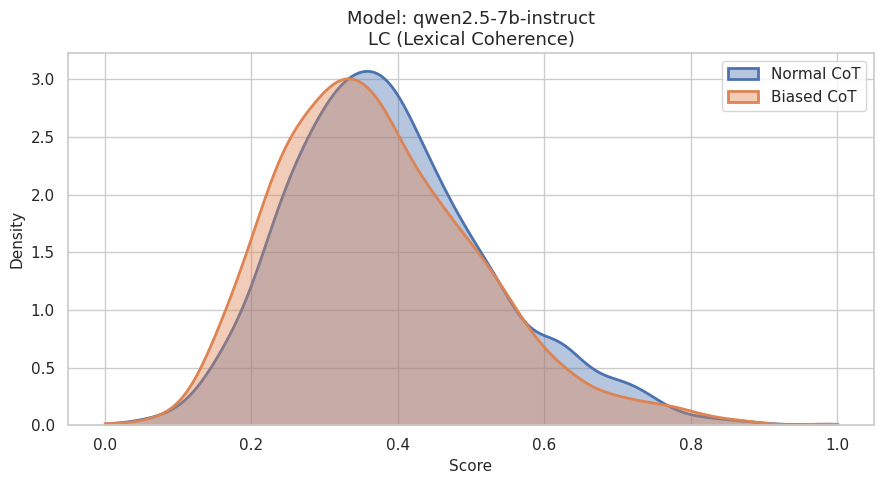


[统计分析 - LC (Lexical Coherence)]
  Normal 均值: 0.3912 | Biased 均值: 0.3748
  t-statistic: 3.4524
  p-value: 5.6230e-04
  效应量 (Cohen's d): 0.1174
  结论: 两组分布极具统计显著性 (p < 0.001)
  差异程度: 极小 (Negligible)
--------------------------------------------------


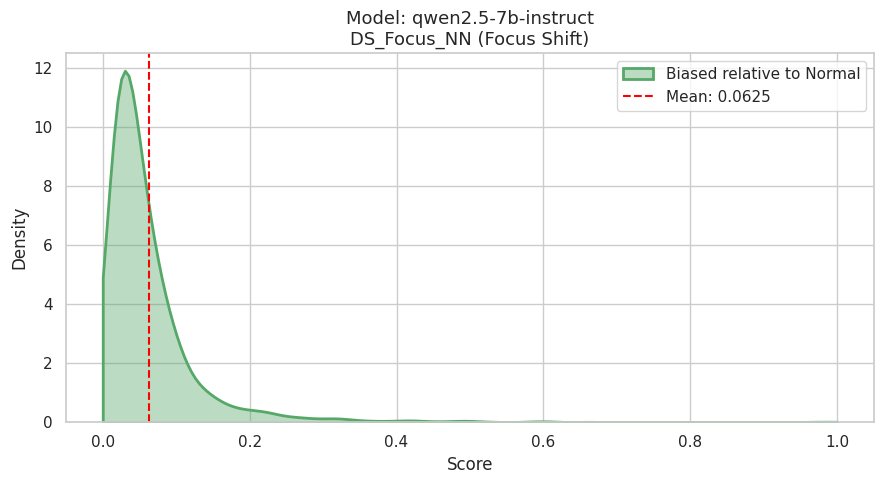


[描述性统计 - DS_Focus_NN (Focus Shift)]
  均值: 0.0625 | 中位数: 0.0415
--------------------------------------------------


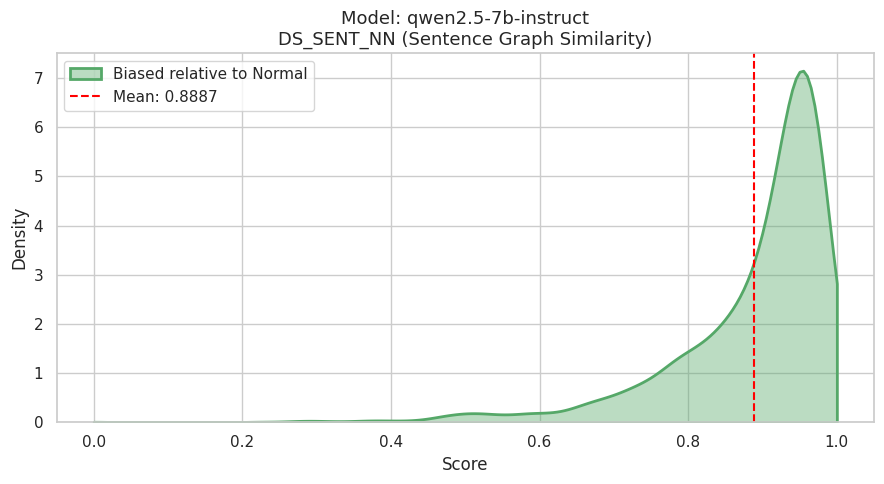


[描述性统计 - DS_SENT_NN (Sentence Graph Similarity)]
  均值: 0.8887 | 中位数: 0.9298
--------------------------------------------------

######################################################################
### 最终统计报告与绘图: llama3.1-8b-instruct (已归一化至 [0-1])
######################################################################


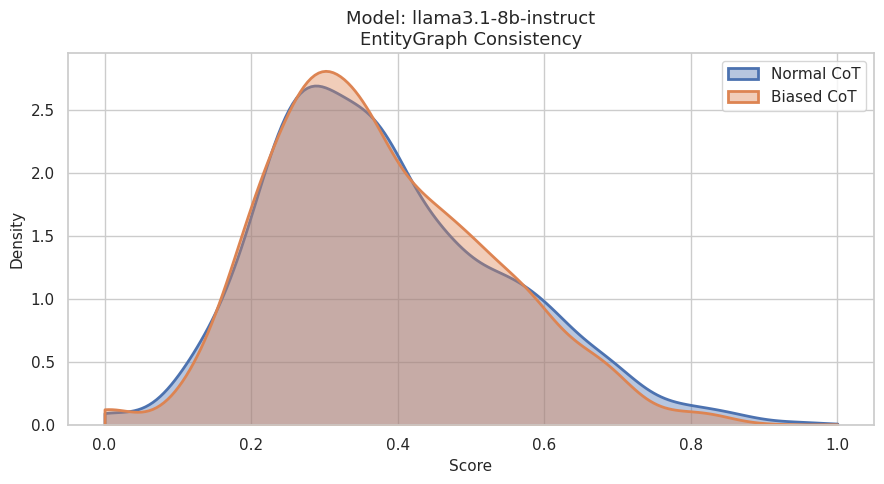


[统计分析 - EntityGraph Consistency]
  Normal 均值: 0.3811 | Biased 均值: 0.3749
  t-statistic: 1.0733
  p-value: 2.8321e-01
  效应量 (Cohen's d): 0.0387
  结论: 两组分布无显著差异 (p > 0.05)
  差异程度: 极小 (Negligible)
--------------------------------------------------


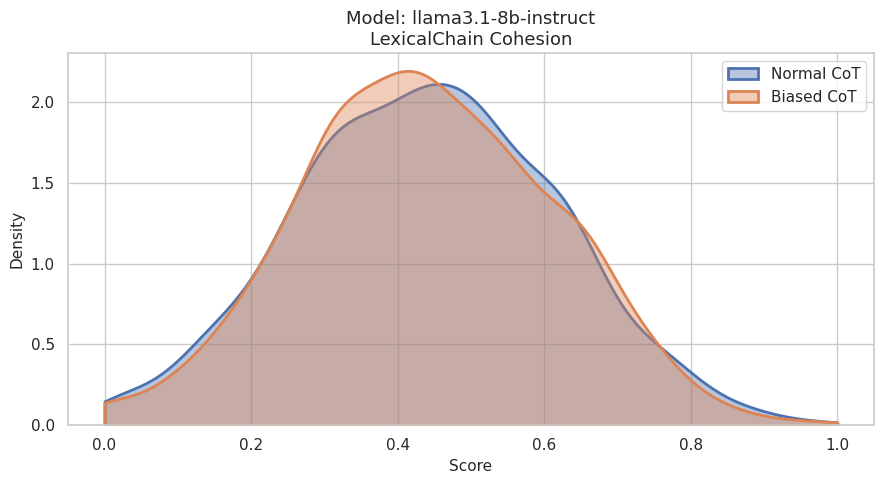


[统计分析 - LexicalChain Cohesion]
  Normal 均值: 0.4398 | Biased 均值: 0.4385
  t-statistic: 0.1977
  p-value: 8.4326e-01
  效应量 (Cohen's d): 0.0071
  结论: 两组分布无显著差异 (p > 0.05)
  差异程度: 极小 (Negligible)
--------------------------------------------------


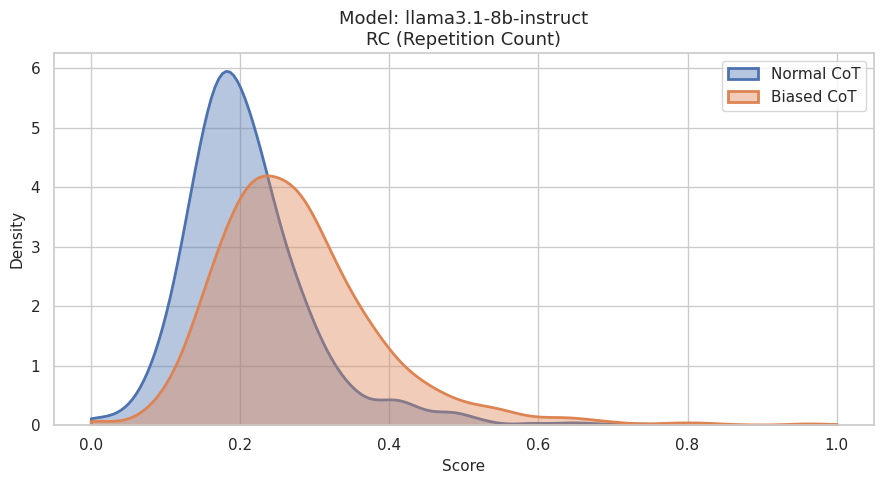


[统计分析 - RC (Repetition Count)]
  Normal 均值: 0.2123 | Biased 均值: 0.2793
  t-statistic: -17.3436
  p-value: 3.2070e-64
  效应量 (Cohen's d): -0.6260
  结论: 两组分布极具统计显著性 (p < 0.001)
  差异程度: 显著 (Large)
--------------------------------------------------


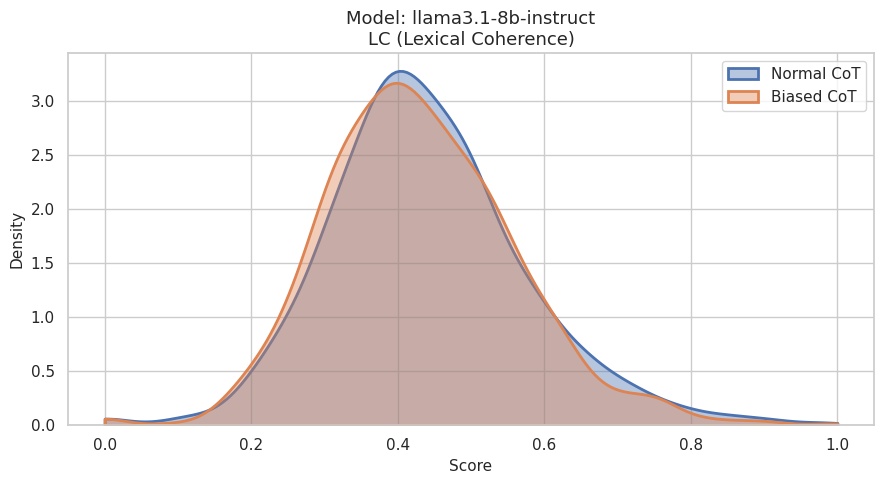


[统计分析 - LC (Lexical Coherence)]
  Normal 均值: 0.4394 | Biased 均值: 0.4299
  t-statistic: 1.9717
  p-value: 4.8738e-02
  效应量 (Cohen's d): 0.0712
  结论: 两组分布具有统计显著性 (p < 0.05)
  差异程度: 极小 (Negligible)
--------------------------------------------------


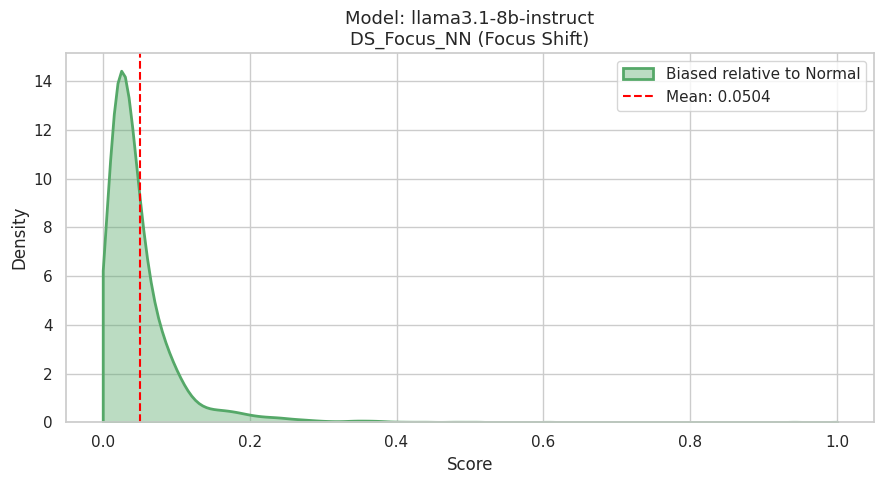


[描述性统计 - DS_Focus_NN (Focus Shift)]
  均值: 0.0504 | 中位数: 0.0335
--------------------------------------------------


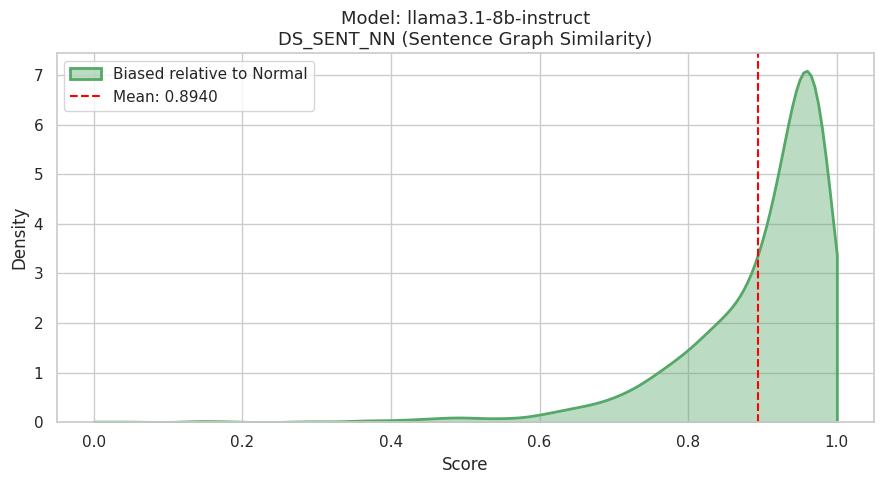


[描述性统计 - DS_SENT_NN (Sentence Graph Similarity)]
  均值: 0.8940 | 中位数: 0.9326
--------------------------------------------------

######################################################################
### 最终统计报告与绘图: gemma-2-9b-it (已归一化至 [0-1])
######################################################################


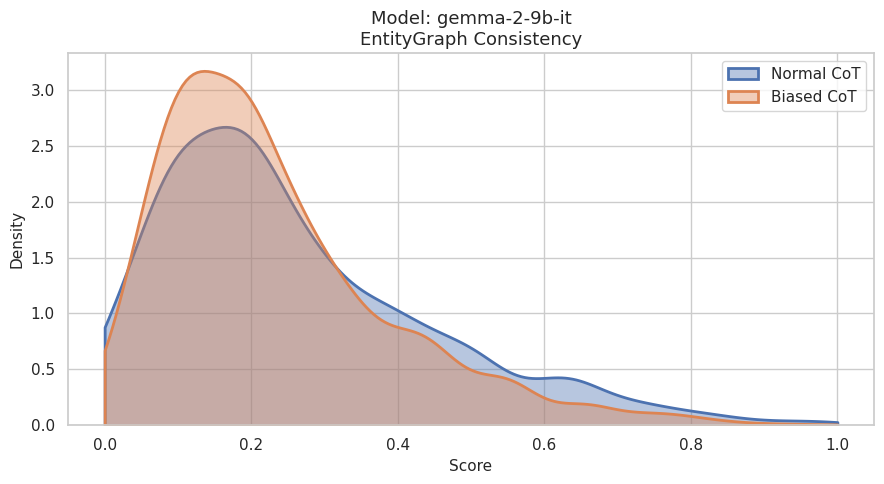


[统计分析 - EntityGraph Consistency]
  Normal 均值: 0.2586 | Biased 均值: 0.2310
  t-statistic: 4.8814
  p-value: 1.0975e-06
  效应量 (Cohen's d): 0.1581
  结论: 两组分布极具统计显著性 (p < 0.001)
  差异程度: 极小 (Negligible)
--------------------------------------------------


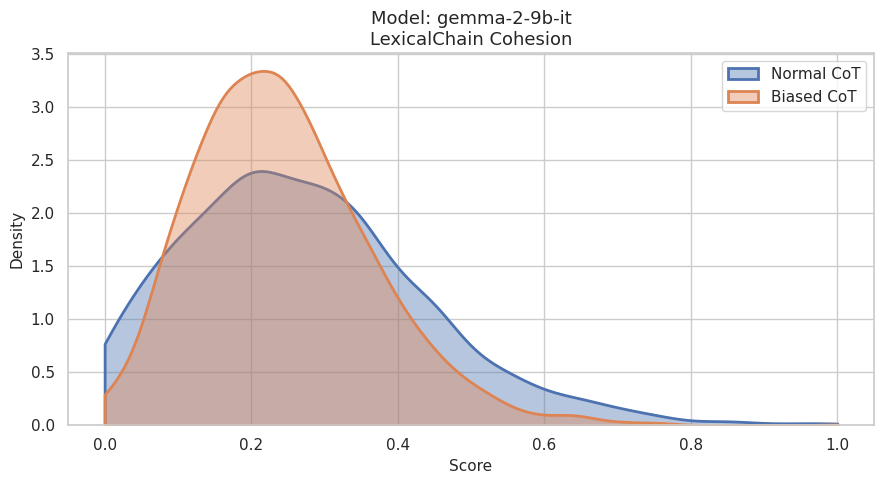


[统计分析 - LexicalChain Cohesion]
  Normal 均值: 0.2710 | Biased 均值: 0.2432
  t-statistic: 5.9013
  p-value: 3.9491e-09
  效应量 (Cohen's d): 0.1912
  结论: 两组分布极具统计显著性 (p < 0.001)
  差异程度: 极小 (Negligible)
--------------------------------------------------


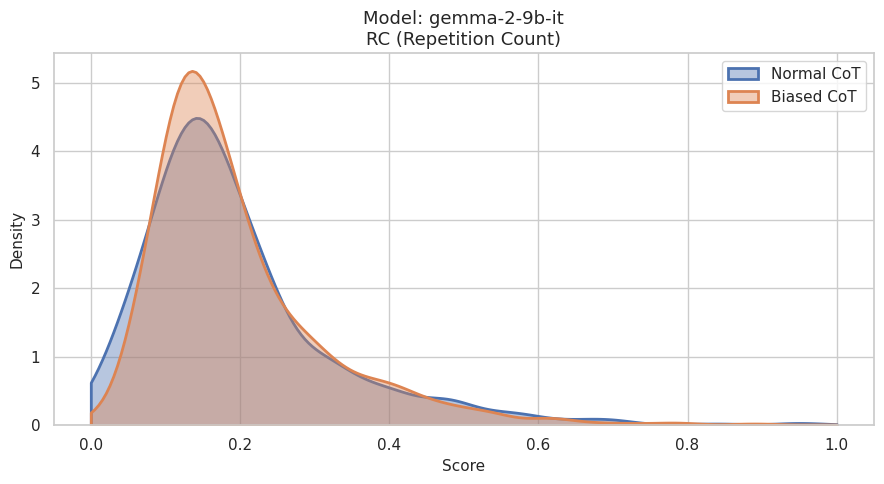


[统计分析 - RC (Repetition Count)]
  Normal 均值: 0.1958 | Biased 均值: 0.1979
  t-statistic: -0.5142
  p-value: 6.0714e-01
  效应量 (Cohen's d): -0.0167
  结论: 两组分布无显著差异 (p > 0.05)
  差异程度: 极小 (Negligible)
--------------------------------------------------


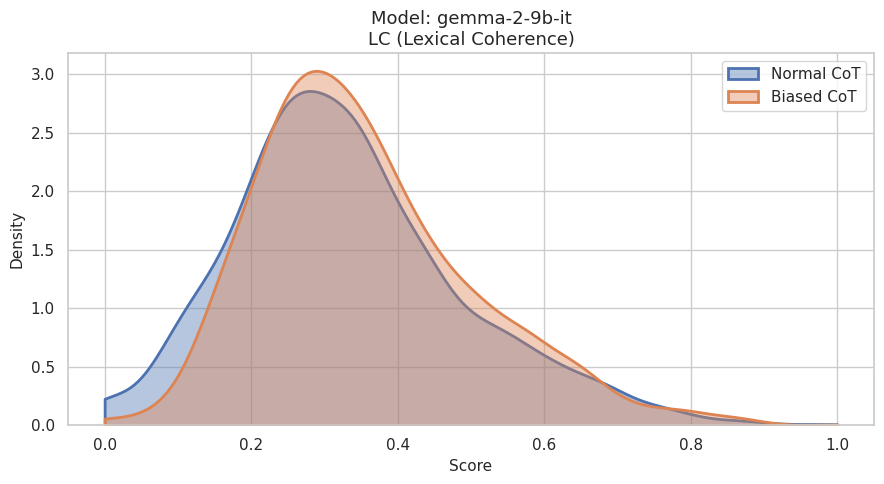


[统计分析 - LC (Lexical Coherence)]
  Normal 均值: 0.3314 | Biased 均值: 0.3543
  t-statistic: -4.6061
  p-value: 4.2381e-06
  效应量 (Cohen's d): -0.1492
  结论: 两组分布极具统计显著性 (p < 0.001)
  差异程度: 极小 (Negligible)
--------------------------------------------------


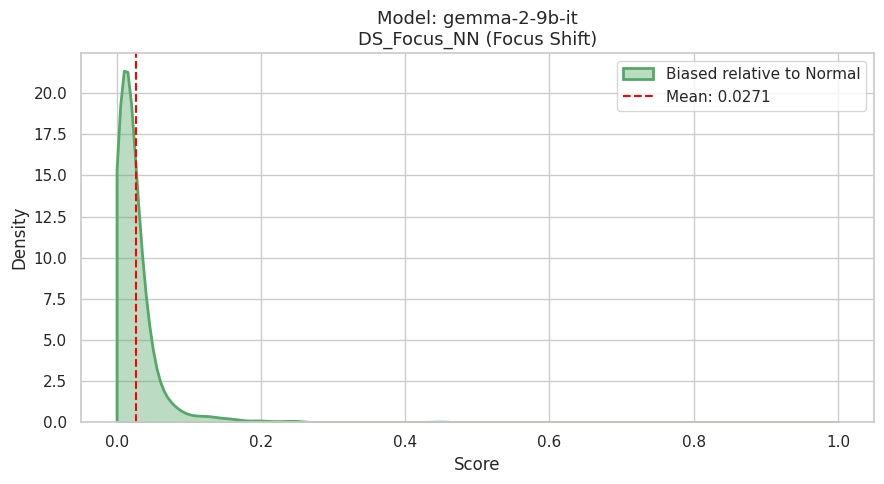


[描述性统计 - DS_Focus_NN (Focus Shift)]
  均值: 0.0271 | 中位数: 0.0149
--------------------------------------------------


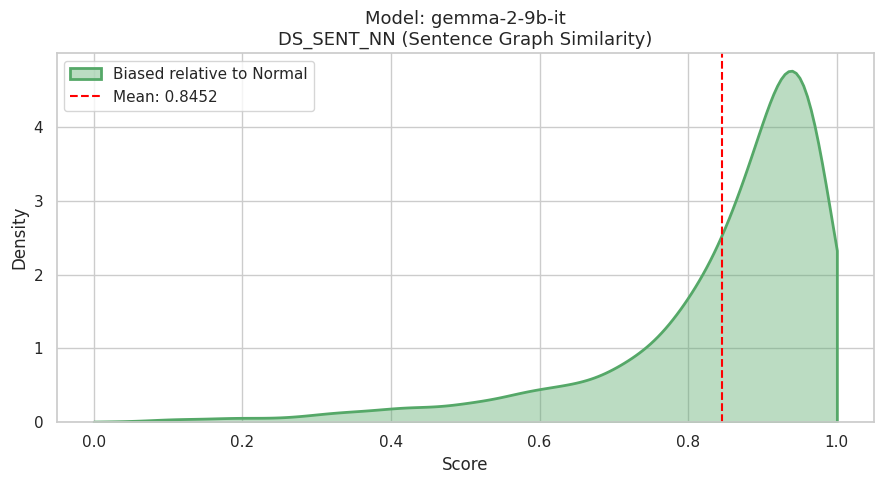


[描述性统计 - DS_SENT_NN (Sentence Graph Similarity)]
  均值: 0.8452 | 中位数: 0.8979
--------------------------------------------------

✨ 所有模型分析报告已生成完毕！


In [ ]:
import os
import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import gaussian_kde
from scipy import stats

# ========== Original Code Core Logic (Path-related changes only) ==========
# Get all processed result files
current_dir = './'  # Current Colab directory (default /content/)
processed_files = [f for f in os.listdir(current_dir)
                   if f.endswith('_disco_sampled_2000.csv')]
sns.set_theme(style="whitegrid")
palette = sns.color_palette("deep")
colors = {"Normal CoT": palette[0], "Biased CoT": palette[1], "Relative Score": palette[2]}


# Key modification: input_dir unified to current_dir (ensures correct read path)
input_dir = current_dir  # Keep consistent with current directory to avoid path errors

for p_file in processed_files:
    m_name = p_file.split('_')[0]
    data = pd.read_csv(os.path.join(input_dir, p_file))

    # Create a temporary copy for plotting and perform normalization
    plot_data = data.copy()

    # Find all column names that need to be normalized (extract from structure_metrics and relative_metrics)
    cols_to_norm = ['n_eg', 'b_eg', 'n_lc', 'b_lc', 'n_rc', 'b_rc', 'n_lc_score', 'b_lc_score', 'ds_focus', 'ds_sent']

    for col in cols_to_norm:
        if col in plot_data.columns:
            c_min = plot_data[col].min()
            c_max = plot_data[col].max()
            if c_max != c_min:
                plot_data[col] = (plot_data[col] - c_min) / (c_max - c_min)
            else:
                plot_data[col] = 0.0  # If all column values are the same, set to 0

    print("\n" + "#"*70)
    print(f"### Final statistical report and plotting: {m_name} (normalized to [0-1])")
    print("#"*70)

    # 1. Structural feature analysis (comparison plot)
    structure_metrics = [
        ('n_eg', 'b_eg', 'EntityGraph Consistency'),
        ('n_lc', 'b_lc', 'LexicalChain Cohesion'),
        ('n_rc', 'b_rc', 'RC (Repetition Count)'),
        ('n_lc_score', 'b_lc_score', 'LC (Lexical Coherence)')
    ]

    for n_col, b_col, title in structure_metrics:
        if n_col in plot_data.columns and b_col in plot_data.columns:
            # Call your defined function, passing the normalized data
            plot_dual_density(plot_data, m_name, n_col, b_col, title)

    # 2. Relative feature analysis (single density plot)
    relative_metrics = [
        ('ds_focus', 'DS_Focus_NN (Focus Shift)'),
        ('ds_sent', 'DS_SENT_NN (Sentence Graph Similarity)')
    ]

    for col, title in relative_metrics:
        if col in plot_data.columns:
            # Call your defined function
            plot_single_density(plot_data, m_name, col, title)

print("\n✨ All model analysis reports have been generated!")

# **Semantic Drift**

In [ ]:
import torch
from sentence_transformers import SentenceTransformer, util
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import os
from tqdm import tqdm

# --- 1. Configuration and Model Initialization ---
device = "cuda" if torch.cuda.is_available() else "cpu"
st_model = SentenceTransformer('sentence-transformers/all-mpnet-base-v2').to(device)

sns.set_theme(style="whitegrid")
palette = sns.color_palette("deep")
main_color = palette[2]
ref_color = "gray"

def calculate_semantic_drift_with_shuffle(texts_normal, texts_bias, batch_size=32):
    """Calculates metrics and displays progress during encoding"""
    # 1. Encode vectors
    emb_normal = st_model.encode(texts_normal, batch_size=batch_size, convert_to_tensor=True, show_progress_bar=True)
    emb_bias = st_model.encode(texts_bias, batch_size=batch_size, convert_to_tensor=True, show_progress_bar=True)

    # 2. Calculate [Pairwise Similarity]
    pairwise_sims = torch.diag(util.cos_sim(emb_normal, emb_bias)).cpu().numpy()

    # 3. Calculate [Random Pair Similarity] (Shuffle Baseline)
    random_indices = torch.randperm(emb_bias.size(0))
    emb_bias_shuffled = emb_bias[random_indices]
    random_sims = torch.diag(util.cos_sim(emb_normal, emb_bias_shuffled)).cpu().numpy()

    # 4. Calculate global centroid metrics (for console report)
    centroid_normal = torch.mean(emb_normal, dim=0, keepdim=True)
    centroid_bias = torch.mean(emb_bias, dim=0, keepdim=True)
    centroid_sim = util.cos_sim(centroid_normal, centroid_bias).item()
    global_centroid_dist = 1 - centroid_sim

    return pairwise_sims, random_sims, global_centroid_dist, centroid_sim

def calculate_cohens_d(group1, group2):
    n1, n2 = len(group1), len(group2)
    var1, var2 = np.var(group1, ddof=1), np.var(group2, ddof=1)
    pooled_std = np.sqrt(((n1 - 1) * var1 + (n2 - 1) * var2) / (n1 + n2 - 2))
    return (np.mean(group1) - np.mean(group2)) / pooled_std if pooled_std != 0 else 0

Total Files Progress:   0%|          | 0/3 [00:00<?, ?it/s]


>>> Analyzing Model: qwen2.5-7b-instruct_combined


Batches:   0%|          | 0/383 [00:00<?, ?it/s]

Batches:   0%|          | 0/383 [00:00<?, ?it/s]

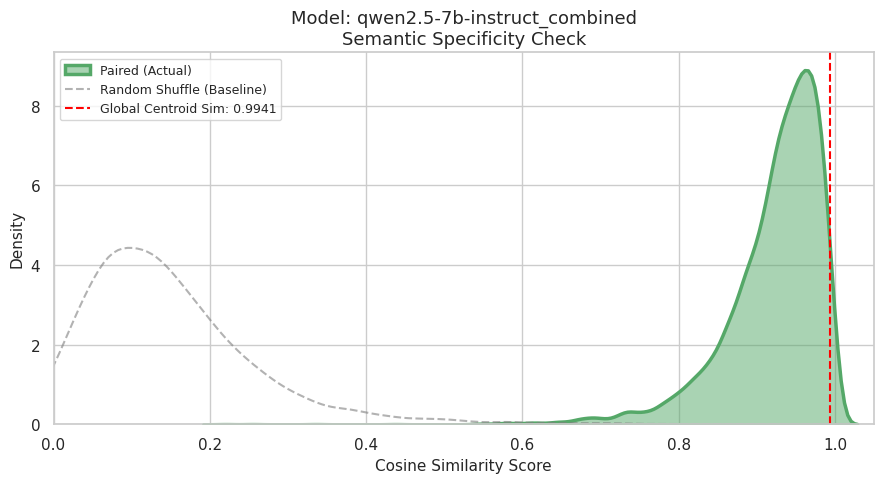

[统计分析 - Semantic Drift Analysis]
  全局质心距离: 0.0059
  平均语义重合度 (Paired): 0.9216
  平均随机重合度 (Random): 0.1458
  t-statistic: 681.6731 | p-value: 0.0000e+00 | Cohen's d: 8.7158


Total Files Progress:  33%|███▎      | 1/3 [05:31<11:02, 331.11s/it]

  结果已保存至: ./analyzed_results2/qwen2.5-7b-instruct_combined_comprehensive_analyzed.csv
--------------------------------------------------

>>> Analyzing Model: gemma-2-9b-it_combined


Batches:   0%|          | 0/384 [00:00<?, ?it/s]

Batches:   0%|          | 0/384 [00:00<?, ?it/s]

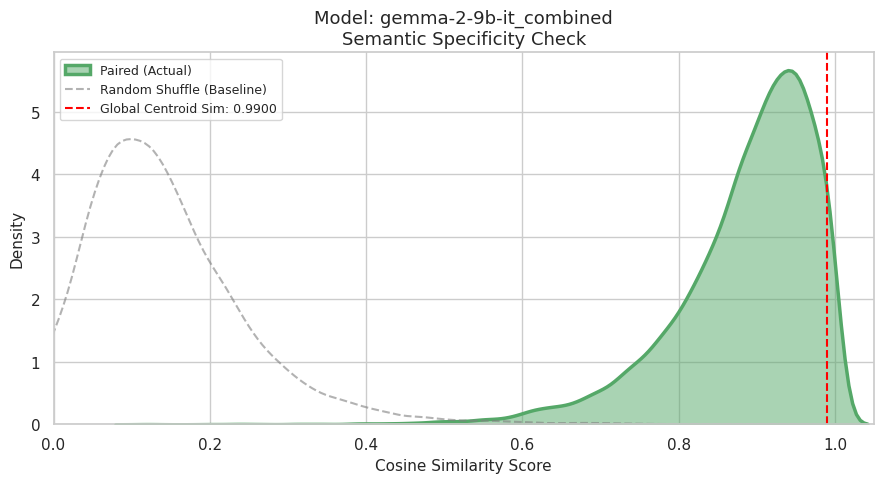

[统计分析 - Semantic Drift Analysis]
  全局质心距离: 0.0100
  平均语义重合度 (Paired): 0.8856
  平均随机重合度 (Random): 0.1421
  t-statistic: 595.5395 | p-value: 0.0000e+00 | Cohen's d: 7.6002


Total Files Progress:  67%|██████▋   | 2/3 [09:49<04:48, 288.54s/it]

  结果已保存至: ./analyzed_results2/gemma-2-9b-it_combined_comprehensive_analyzed.csv
--------------------------------------------------

>>> Analyzing Model: llama3.1-8b-instruct_combined


Batches:   0%|          | 0/376 [00:00<?, ?it/s]

Batches:   0%|          | 0/376 [00:00<?, ?it/s]

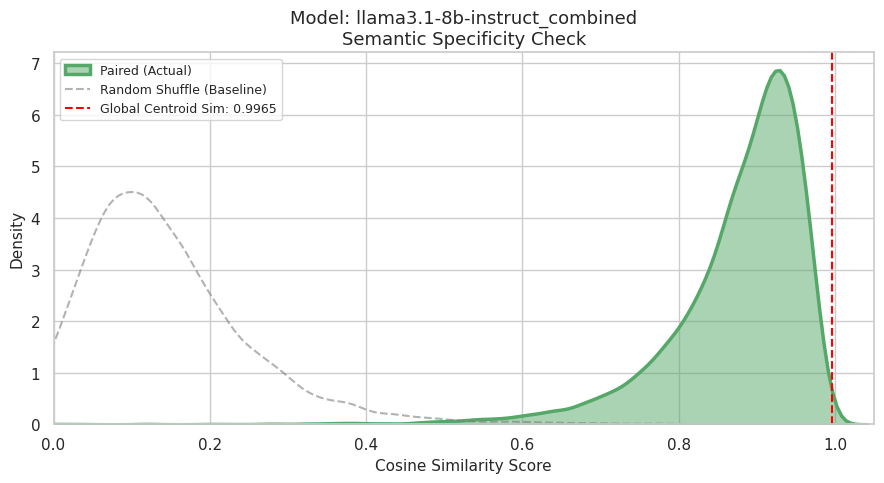

[统计分析 - Semantic Drift Analysis]
  全局质心距离: 0.0035
  平均语义重合度 (Paired): 0.8741
  平均随机重合度 (Random): 0.1429
  t-statistic: 567.8202 | p-value: 0.0000e+00 | Cohen's d: 7.3217


Total Files Progress: 100%|██████████| 3/3 [15:15<00:00, 305.21s/it]

  结果已保存至: ./analyzed_results2/llama3.1-8b-instruct_combined_comprehensive_analyzed.csv
--------------------------------------------------


In [ ]:
# --- 2. Main Loop Analysis ---
input_dir = './' # Please ensure the path is correct
output_dir = './analyzed_results2/'
if not os.path.exists(output_dir):
    os.makedirs(output_dir)

model_files = [f for f in os.listdir(input_dir) if f.endswith('.csv') and not f.endswith('_analyzed.csv')]

for file_name in tqdm(model_files, desc="Total Files Progress"):
    file_path = os.path.join(input_dir, file_name);
    df = pd.read_csv(file_path).dropna(subset=['cot_model_output', 'cot_bias_output'])
    m_name = file_name.replace(".csv", "")

    print(f"\n" + "="*30)
    print(f">>> Analyzing Model: {m_name}")
    print(f"="*30)

    # 1. Get text
    normal_texts = df['cot_model_output'].astype(str).tolist()
    bias_texts = df['cot_bias_output'].astype(str).tolist()

    # 2. Calculate metrics
    paired_sims, random_sims, c_dist_global, c_sim_global = calculate_semantic_drift_with_shuffle(normal_texts, bias_texts)

    # --- New: Write pairwise metrics to DataFrame ---
    # Average semantic overlap for each pair
    df['semantic_overlap'] = paired_sims
    # Random background overlap for each column
    df['random_overlap_baseline'] = random_sims
    # Centroid distance for each pair (1 - similarity)
    df['centroid_distance'] = 1 - paired_sims
    # --------------------------------------

    # 3. Visualization
    plt.figure(figsize=(9, 5))
    sns.kdeplot(data=paired_sims, fill=True, color=main_color, alpha=0.5, linewidth=2.5, label="Paired (Actual)")
    sns.kdeplot(data=random_sims, color=ref_color, linestyle="--", alpha=0.6, linewidth=1.5, label="Random Shuffle (Baseline)")
    plt.axvline(x=c_sim_global, color='red', linestyle='--', label=f'Global Centroid Sim: {c_sim_global:.4f}')

    plt.title(f"Model: {m_name}\nSemantic Specificity Check", fontsize=13)
    plt.xlabel("Cosine Similarity Score", fontsize=11)
    plt.ylabel("Density", fontsize=11)
    plt.xlim(0, 1.05)
    plt.legend(fontsize=9)
    plt.tight_layout()
    plt.show()

    # 4. Statistical report (displayed only in console)
    print(f"[Statistical Analysis - Semantic Drift Analysis]")
    print(f"  Global Centroid Distance: {c_dist_global:.4f}")
    print(f"  Average Semantic Overlap (Paired): {np.mean(paired_sims):.4f}")
    print(f"  Average Random Overlap (Random): {np.mean(random_sims):.4f}")

    t_stat, p_val = stats.ttest_ind(paired_sims, random_sims)
    d = calculate_cohens_d(paired_sims, random_sims)

    print(f"  t-statistic: {t_stat:.4f} | p-value: {p_val:.4e} | Cohen's d: {d:.4f}")

    # 5. Export CSV
    save_path = os.path.join(output_dir, f"{m_name}_comprehensive_analyzed.csv")
    df.to_csv(save_path, index=False, encoding='utf-8-sig')
    print(f"  Results saved to: {save_path}")
    print("-" * 50)

Processing Models:   0%|          | 0/3 [00:00<?, ?it/s]


>>> 深度分析模型: gemma-2-9b-it_combined


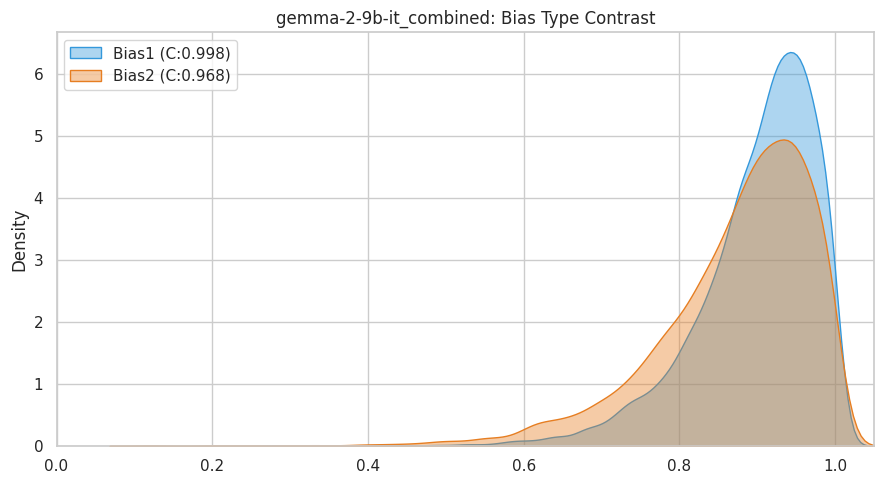


[统计分析 - Bias Type]
  Ref 均值: 0.8996 | Comp 均值: 0.8716
  t-statistic: 17.3140 | p-value: 2.5414e-66 | Cohen's d: 0.3125


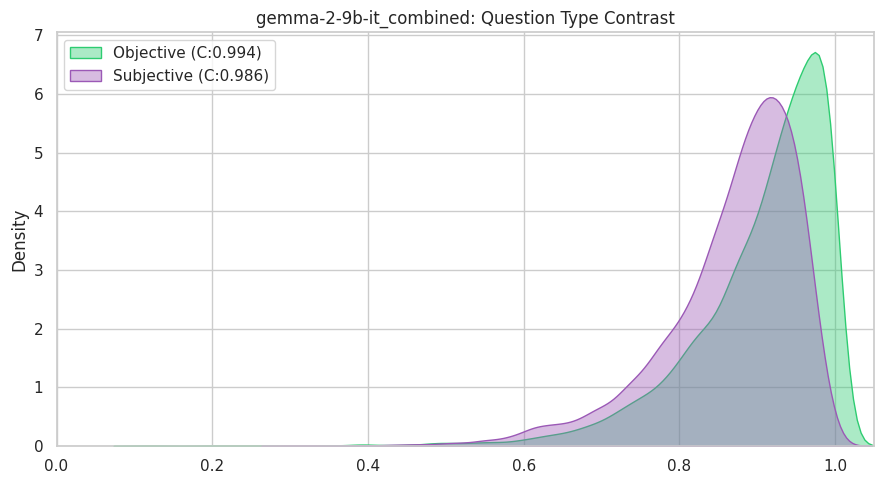


[统计分析 - Question Type]
  Ref 均值: 0.9041 | Comp 均值: 0.8671
  t-statistic: 23.0397 | p-value: 5.0885e-115 | Cohen's d: 0.4158


Processing Models:  33%|███▎      | 1/3 [08:00<16:01, 480.89s/it]


------------------------------------------------------------

>>> 深度分析模型: llama3.1-8b-instruct_combined


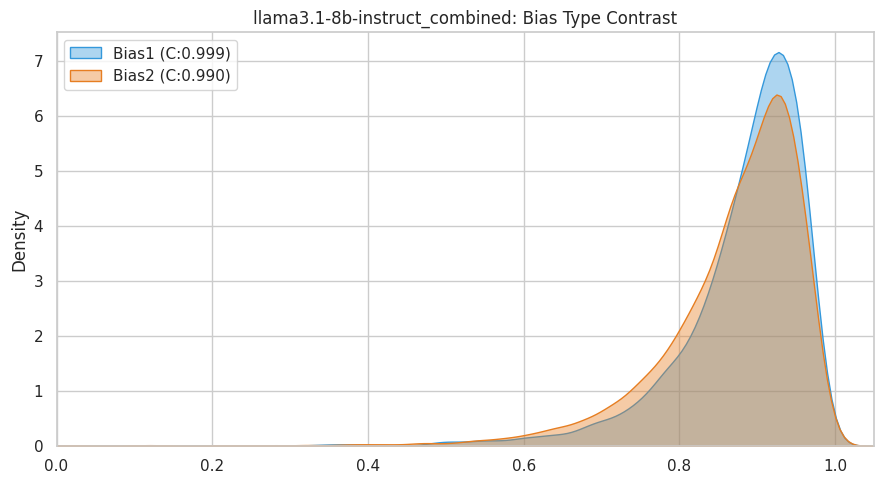


[统计分析 - Bias Type]
  Ref 均值: 0.8804 | Comp 均值: 0.8679
  t-statistic: 7.5403 | p-value: 5.0264e-14 | Cohen's d: 0.1375


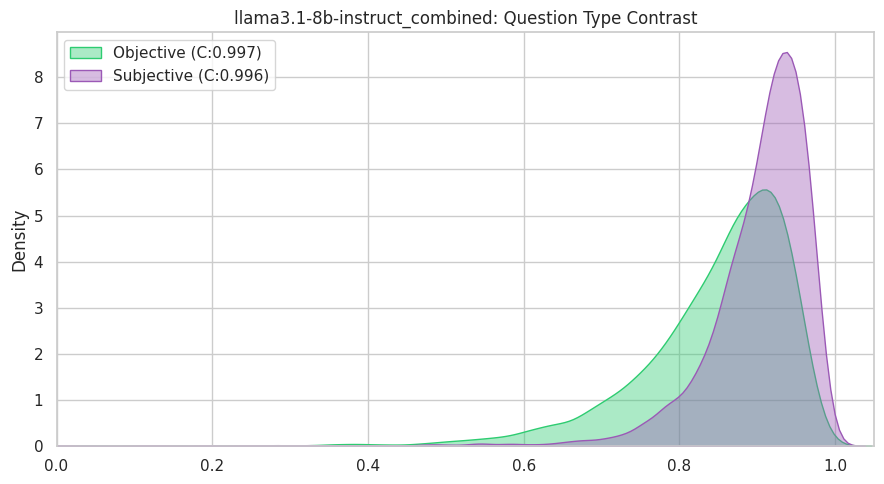


[统计分析 - Question Type]
  Ref 均值: 0.8459 | Comp 均值: 0.9015
  t-statistic: -35.1885 | p-value: 3.8078e-257 | Cohen's d: -0.6444


Processing Models:  67%|██████▋   | 2/3 [18:38<09:33, 573.15s/it]


------------------------------------------------------------

>>> 深度分析模型: qwen2.5-7b-instruct_combined


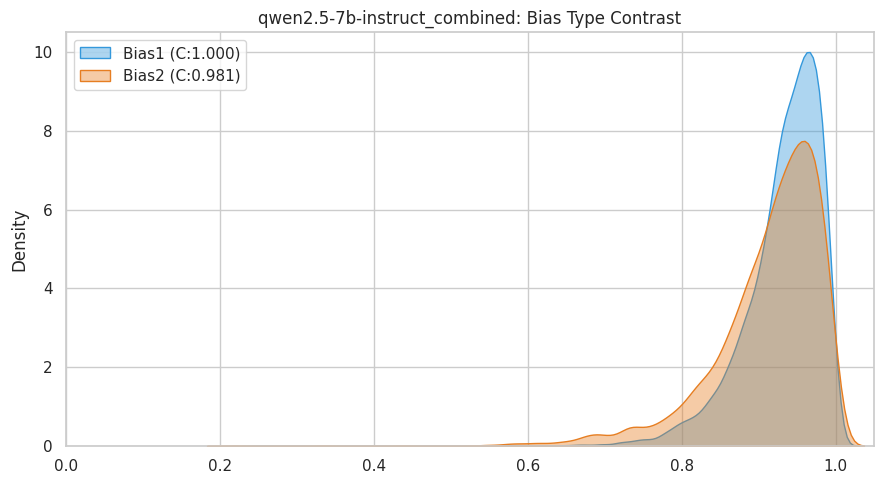


[统计分析 - Bias Type]
  Ref 均值: 0.9314 | Comp 均值: 0.9119
  t-statistic: 17.5513 | p-value: 4.7950e-68 | Cohen's d: 0.3173


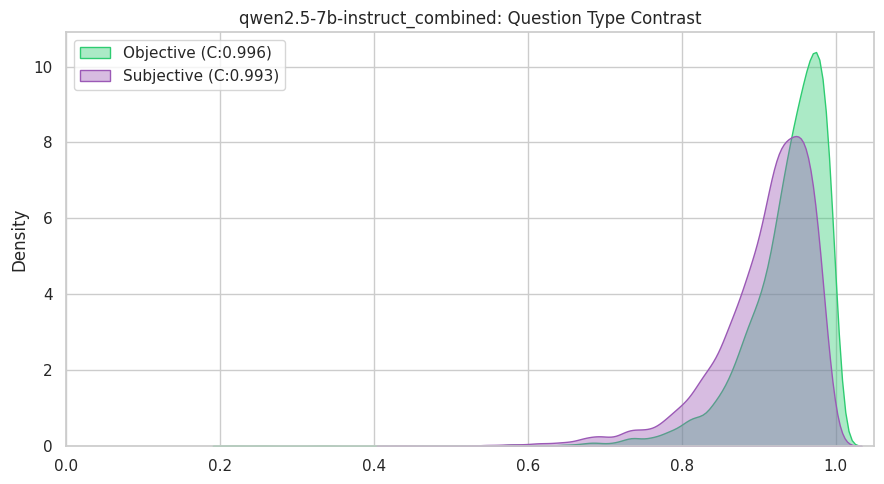


[统计分析 - Question Type]
  Ref 均值: 0.9354 | Comp 均值: 0.9080
  t-statistic: 25.0181 | p-value: 1.0472e-134 | Cohen's d: 0.4521


Processing Models: 100%|██████████| 3/3 [29:14<00:00, 584.73s/it]


------------------------------------------------------------


In [ ]:
import torch
from sentence_transformers import SentenceTransformer, util
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import os
from tqdm import tqdm

# --- 1. Initialization Settings ---
device = "cuda" if torch.cuda.is_available() else "cpu"
st_model = SentenceTransformer('sentence-transformers/all-mpnet-base-v2').to(device)

sns.set_theme(style="whitegrid")
bias_colors = ["#3498db", "#e67e22"]
q_colors = ["#2ecc71", "#9b59b6"]

# Recommended to set a unified output directory
output_dir = './analyzed_results3/'
if not os.path.exists(output_dir):
    os.makedirs(output_dir)

# --- 2. Enhanced Core Calculation Function ---
def get_detailed_metrics_v2(df_sub):
    """
    Calculates subgroup distributions and returns:
    1. sims (for plotting/statistics)
    2. c_sim (global centroid)
    3. df_analyzed (DataFrame copy with added columns)
    """
    if len(df_sub) == 0:
        return None, None, None

    texts_n = df_sub['cot_model_output'].astype(str).tolist()
    texts_b = df_sub['cot_bias_output'].astype(str).tolist()

    # 1. Encoding (GPU accelerated)
    emb_n = st_model.encode(texts_n, batch_size=32, convert_to_tensor=True, show_progress_bar=False)
    emb_b = st_model.encode(texts_b, batch_size=32, convert_to_tensor=True, show_progress_bar=False)

    # 2. Calculate [Pairwise Semantic Overlap]
    sims = torch.diag(util.cos_sim(emb_n, emb_b)).cpu().numpy()

    # 3. Calculate [Pairwise Centroid Distance]
    # For a single pair of samples, the centroid distance is 1 - Cosine Similarity
    dists = 1 - sims

    # 4. Calculate [Random Overlap] (Random Overlap / Baseline)
    # Shuffle randomly within the current subgroup
    rand_idx = torch.randperm(emb_b.size(0))
    emb_b_rand = emb_b[rand_idx]
    random_sims = torch.diag(util.cos_sim(emb_n, emb_b_rand)).cpu().numpy()

    # 5. Calculate global centroid similarity (for plotting)
    c_sim = util.cos_sim(torch.mean(emb_n, dim=0, keepdim=True),
                         torch.mean(emb_b, dim=0, keepdim=True)).item()

    # Save results to DataFrame copy
    df_res = df_sub.copy()
    df_res['semantic_overlap'] = sims
    df_res['centroid_distance'] = dists
    df_res['random_overlap'] = random_sims

    return sims, c_sim, df_res

def calculate_cohens_d(group1, group2):
    n1, n2 = len(group1), len(group2)
    var1, var2 = np.var(group1, ddof=1), np.var(group2, ddof=1)
    pooled_std = np.sqrt(((n1 - 1) * var1 + (n2 - 1) * var2) / (n1 + n2 - 2))
    return (np.mean(group1) - np.mean(group2)) / pooled_std if pooled_std != 0 else 0

def print_stats_report(group_normal, group_bias, feature_name):
    t_stat, p_val = stats.ttest_ind(group_normal, group_bias, equal_var=False)
    d = calculate_cohens_d(group_normal, group_bias)
    print(f"\n[Statistical Analysis - {feature_name}]")
    print(f"  Ref Mean: {np.mean(group_normal):.4f} | Comp Mean: {np.mean(group_bias):.4f}")
    print(f"  t-statistic: {t_stat:.4f} | p-value: {p_val:.4e} | Cohen's d: {d:.4f}")

# --- 3. Main Loop Analysis ---
# Ensure input_dir path is correct
input_dir = '/content/drive/MyDrive/Colab_Notebooks/jianfei目前暂时借用/sycophancy/bias_vs_unbias_linguistic_feature_data/combined'
model_files = [f for f in os.listdir(input_dir) if f.endswith('.csv') and not f.endswith('_analyzed.csv')]

for file_name in tqdm(model_files, desc="Processing Models"):
    file_path = os.path.join(input_dir, file_name)
    df = pd.read_csv(file_path).dropna(subset=['cot_model_output', 'cot_bias_output', 'bias_type', 'question_type'])
    m_name = file_name.replace(".csv", "")

    print(f"\n" + "="*50)
    print(f">>> In-depth analysis model: {m_name}")
    print(f"="*50)

    # --- A. Bias Type Analysis and Merged Export ---
    sims_b1, c_b1, df_b1_analyzed = get_detailed_metrics_v2(df[df['bias_type'] == 'bias1'])
    sims_b2, c_b2, df_b2_analyzed = get_detailed_metrics_v2(df[df['bias_type'] == 'bias2'])

    if sims_b1 is not None and sims_b2 is not None:
        # Plotting and reporting
        plt.figure(figsize=(9, 5))
        sns.kdeplot(data=sims_b1, fill=True, color=bias_colors[0], label=f"Bias1 (C:{c_b1:.3f})", alpha=0.4)
        sns.kdeplot(data=sims_b2, fill=True, color=bias_colors[1], label=f"Bias2 (C:{c_b2:.3f})", alpha=0.4)
        plt.title(f"{m_name}: Bias Type Contrast")
        plt.xlim(0, 1.05), plt.legend(), plt.tight_layout(), plt.show()
        print_stats_report(sims_b1, sims_b2, "Bias Type")

        # Export independent Bias CSV
        bias_final_df = pd.concat([df_b1_analyzed, df_b2_analyzed])
        bias_final_df.to_csv(os.path.join(output_dir, f"{m_name}_bias_analyzed.csv"), index=False, encoding='utf-8-sig')

    # --- B. Question Type Analysis and Merged Export ---
    sims_obj, c_obj, df_obj_analyzed = get_detailed_metrics_v2(df[df['question_type'] == 'objective'])
    sims_sub, c_sub, df_sub_analyzed = get_detailed_metrics_v2(df[df['question_type'] == 'subjective'])

    if sims_obj is not None and sims_sub is not None:
        # Plotting and reporting
        plt.figure(figsize=(9, 5))
        sns.kdeplot(data=sims_obj, fill=True, color=q_colors[0], label=f"Objective (C:{c_obj:.3f})", alpha=0.4)
        sns.kdeplot(data=sims_sub, fill=True, color=q_colors[1], label=f"Subjective (C:{c_sub:.3f})", alpha=0.4)
        plt.title(f"{m_name}: Question Type Contrast")
        plt.xlim(0, 1.05), plt.legend(), plt.tight_layout(), plt.show()
        print_stats_report(sims_obj, sims_sub, "Question Type")

        # Export independent Question CSV
        q_final_df = pd.concat([df_obj_analyzed, df_sub_analyzed])
        q_final_df.to_csv(os.path.join(output_dir, f"{m_name}_question_analyzed.csv"), index=False, encoding='utf-8-sig')

    print("\n" + "-"*60)

In [ ]:
from google.colab import runtime

# Example: Automatically disconnect session after task completion
print("Task completed, preparing to disconnect session...")
# Disconnect session (will terminate all running code and release resources)
runtime.unassign()

# The following code will not execute (session already disconnected)
print("This line of code will not run")